# Transformer reconstruction model for visitor anomalies

This notebook represents reconstruction approach:

1. Build 24-hour windows for every sensor.
2. Reconstruct the **visitor sequence** in the same window.
3. Combine overlapping reconstructions into one prediction per timestamp.
4. Learn an IQR threshold from validation errors.

Important corrections compared with the earlier notebook:

- calendar features are recomputed from the timestamp;
- rows are split chronologically for every sensor before windows are created;
- raw features are projected into Transformer space before embeddings are added;
- the loss is reconstructed, to observe the anomaly pattern;
- validation thresholds are applied;
- overlapping predictions are averaged once before calculating the timestamp error.


In [2]:
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Embedding,Add, MultiHeadAttention, Dropout, LayerNormalization, Reshape, UpSampling1D
from tensorflow.keras import Sequential,Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from pathlib import Path

In [3]:
SEED = 42

tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

## Load and validate the data


In [4]:
df = pd.read_csv('final_data.csv')
df.shape

(9380, 9)

In [5]:
visitor=df['visitors']
print("Min:",visitor.min())
print("Max:", visitor.max())
print("Mean:", visitor.mean())
print("Median:", np.median(visitor))
print("Std:", visitor.std())

Min: 0.0
Max: 977.0
Mean: 42.16236673773987
Median: 18.0
Std: 73.08248747130122


## Cyclic Encoding of Weekdays

Weekdays are encoded using sine and cosine transformations to represent their cyclical nature. This ensures that Sunday (`6`) and Monday (`0`) are treated as neighbouring days.

In [6]:
weekday_sin = np.sin(2*np.pi*df['weekday']/7)
weekday_cos = np.cos(2*np.pi*df['weekday']/7)

In [7]:
#assign weekday_sin and weekday_cos to df
df = df.assign(weekday_sin = weekday_sin, weekday_cos = weekday_cos)

### Encode Sensor IDs

The sensor IDs are UUID strings, which cannot be passed directly to an embedding layer. Therefore, `pd.factorize()` converts every unique sensor ID into an integer starting from `0`.
`sensor_ids_encoded` contains the integer sensor ID corresponding to each window, while `unique_sensors` stores the mapping back to the original UUIDs. `num_sensors` represents the total number of unique sensors.

In [8]:
df = df.sort_values(['SID', 'timestamp']).reset_index(drop=True)
df['sensor_encoded'], unique_sensors = pd.factorize(df['SID'])
num_sensors = len(unique_sensors)

print(df[["SID", "sensor_encoded"]].drop_duplicates())
print("Number of sensors:", num_sensors)

                                       SID  sensor_encoded
0     26213d2d-2954-4312-b42a-a6b323764086               0
335   3cc1e766-97c5-4ed0-92c3-a800b5be8658               1
670   4275b813-3d57-4b01-93a2-7d8271130792               2
1005  444377cc-f3b9-45ed-984c-4a8bb6586feb               3
1340  481da5b9-afd5-44c5-b29b-6c3e23a59bcb               4
1675  4e3bbfd4-bb31-424b-99d7-b67ec0a4e026               5
2010  4ff66154-8c30-4f61-9e54-d5c1744c117c               6
2345  5ee75133-74ce-4a65-ac22-be263ad8566a               7
2680  7d06c31f-aa88-4c5b-8280-565243350ad8               8
3015  b0d968cd-ded3-4953-b99f-2cb5fabd086d               9
3350  b40103c5-1f38-4c15-9781-8788ae4790da              10
3685  b8419dcf-9ac6-4dab-9a7b-8af4718b74e1              11
4020  ba9989f9-0b51-4f44-955c-c4ac37d21bda              12
4355  bb71e93c-fc02-464c-acf0-f2c6c453762d              13
4690  bc5edd25-415e-40fb-8607-ad8c0b10ea4c              14
5025  c294766d-4a58-496f-b00e-665dc626bdea              

### Sensor-Wise Chronological Training and Validation Split

The data are split separately for each sensor. First, the observations of each sensor are sorted chronologically by timestamp. The first `80%` of the rows are assigned to the training set, while the remaining `20%` are assigned to the validation set.

The split is performed before creating the 24-hour windows. This preserves the temporal order and ensures that each sensor is represented in both the training and validation periods.


In [9]:
train_parts = []
validation_parts = []

for sensor_id, sensor_data in df.groupby("SID", sort=False):
    sensor_data = sensor_data.sort_values("timestamp").copy()
    split_position = int(0.8 * len(sensor_data))

    # First 80% of original rows
    train_parts.append(sensor_data.iloc[:split_position])
    
    # Last 20% of original rows
    validation_parts.append(sensor_data.iloc[split_position:])

train_df = pd.concat(train_parts).reset_index(drop=True)
validation_df = pd.concat(validation_parts).reset_index(drop=True)

### Standardize the Visitors Feature

Only the `visitors` feature is standardized because the sine and cosine features are already bounded between `-1` and `1`.
The visitors values are extracted from all windows, reshaped into a two-dimensional array and transformed using `StandardScaler`. This gives the visitors feature approximately zero mean and unit variance. The scaled values are then reshaped back into the original window structure.


In [10]:
scaler = StandardScaler()

train_df["visitors_scaled"] = scaler.fit_transform(train_df[["visitors"]])
validation_df["visitors_scaled"] = scaler.transform( validation_df[["visitors"]])

### Define Input Features and Window Size

The model uses five input features. A window size of `24` represents 24 consecutive hourly observations for each sensor. Therefore, each model input window has the shape `(24, 5)`.

In [11]:
features = ['visitors_scaled', 'hour_sin', 'hour_cos','weekday_sin','weekday_cos']
n_features = len(features)
window_size = 24 #inatializing window size for 24 hours

### Create Sliding Windows for Each Sensor

The data is processed separately for every sensor to ensure that a window never contains observations from different sensors.
For each sensor, a sliding window of 24 consecutive hourly observations is created. The window moves forward by one timestamp at a time, producing:
            Nwindows ​= Nobservations ​− window size+1 
Each generated window stores:
- The feature values with shape `(24, 5)`
- The corresponding sensor ID
- The 24 timestamps included in the window
- The sensor location or name

In [12]:
X_train = []
sensor_train = []
train_sensor_ids = []
train_window_times = []
train_locations = []

for sensor_id in train_df["SID"].unique():
    sensor_data = train_df[train_df["SID"] == sensor_id].sort_values("timestamp")
    values = sensor_data[features].to_numpy(dtype=np.float32)
    names = sensor_data["name"].to_numpy()
    timestamps = sensor_data["timestamp"].to_numpy()
    encoded_id = sensor_data["sensor_encoded"].iloc[0]
    for i in range(len(values) - window_size + 1):
        X_train.append(values[i:i + window_size])
        sensor_train.append(encoded_id)
        train_sensor_ids.append(sensor_id)
        train_window_times.append(timestamps[i:i + window_size])
        train_locations.append(names[i])

X_train = np.asarray(X_train, dtype=np.float32)
sensor_train = np.asarray(sensor_train, dtype=np.int32)
train_sensor_ids = np.asarray(train_sensor_ids)
train_window_times = np.asarray(train_window_times)
train_locations = np.asarray(train_locations)

In [13]:
X_validation = []
sensor_validation = []
validation_sensor_ids = []
validation_window_times = []
validation_locations = []

for sensor_id in validation_df["SID"].unique():
    sensor_data = validation_df[validation_df["SID"] == sensor_id].sort_values("timestamp")
    values = sensor_data[features].to_numpy(dtype=np.float32)
    names = sensor_data["name"].to_numpy()
    timestamps = sensor_data["timestamp"].to_numpy()
    encoded_id = sensor_data["sensor_encoded"].iloc[0]

    for i in range(len(values) - window_size + 1):
        X_validation.append(values[i:i + window_size])
        sensor_validation.append(encoded_id)
        validation_sensor_ids.append(sensor_id)

        validation_window_times.append(timestamps[i:i + window_size])
        validation_locations.append(names[i])

X_validation = np.asarray(X_validation, dtype=np.float32)
sensor_validation = np.asarray(sensor_validation, dtype=np.int32)
validation_sensor_ids = np.asarray(validation_sensor_ids)
validation_window_times = np.asarray(validation_window_times)
validation_locations = np.asarray(validation_locations)

In [14]:
print("Training windows:", X_train.shape)
print("Training sensors:", sensor_train.shape)

print("Validation windows:", X_validation.shape)
print("Validation sensors:", sensor_validation.shape)

Training windows: (6860, 24, 5)
Training sensors: (6860,)
Validation windows: (1232, 24, 5)
Validation sensors: (1232,)


### Combine Training and Validation Windows

The training and validation arrays are combined to generate predictions for the complete dataset. This includes the feature windows, sensor IDs, timestamps and locations.

The combined data should only be used for the final anomaly report, not for model training.


In [15]:
train_data = np.concatenate([X_train, X_validation],axis=0)
sensor_ids_encoded = np.concatenate([sensor_train, sensor_validation],axis=0)
sensor_ids = np.concatenate([train_sensor_ids, validation_sensor_ids],axis=0)
window = np.concatenate([train_window_times, validation_window_times],axis=0)
location = np.concatenate([train_locations, validation_locations],axis=0)


print(train_data.shape)
print(sensor_ids_encoded.shape)

(8092, 24, 5)
(8092,)


### Positional Embedding

The positional embedding provides information about the order of observations within each window. Sine and cosine functions generate a unique representation for every position. The output has the shape `(1, sequence_length, n_features)` and is added to the input features.


In [16]:
#positional embedding
def positional_embedding(sequence_length, n_features):
    position = np.arange(sequence_length)[:,np.newaxis]
    dims = np.arange(n_features)[np.newaxis,:]

    #position formula
    angle_rates = 1 / np.power(10000, (2 * (dims // 2)) / np.float32(n_features))
    angle_rads = position * angle_rates

    #add sin and cos to odd and even indices
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    angle_rads = angle_rads[np.newaxis,:,:]
    
    return tf.cast(angle_rads, dtype = tf.float32)
    

### Transformer Encoder Block

The encoder block applies multi-head self-attention to learn relationships between observations in the 24-hour window. Dropout, residual connections and layer normalization are used for stable training. A feedforward network then transforms the learned representation and returns an output with the same shape as the input.


In [17]:
#build transformer encoder block
def transformer_encoder_block(inputs, head_size, num_heads, ff_dim, dropout = 0.1):
    #multi head self attention
    attn = MultiHeadAttention(key_dim = head_size, num_heads = num_heads,dropout = dropout)(inputs,inputs)
    attn = Dropout(dropout)(attn)
    x = attn + inputs
    x_norm = LayerNormalization()(x)

    #feedforward network
    ff = Dense(ff_dim, activation = "relu")(x_norm)
    ff = Dense(inputs.shape[-1])(ff)
    x = ff + x_norm
    x = LayerNormalization()(x)
    return x
    


### Transformer Autoencoder Model

The model receives feature windows and encoded sensor IDs. The input features are combined with positional and sensor embeddings before passing through multiple Transformer encoder blocks. A latent layer learns the internal representation, and the final dense layer reconstructs the original five input features.


In [18]:
#define model
def model(
    input_shape,
    head_size,
    num_heads,
    ff_dim,
    number_transformer_blocks,
    dropout = 0.1
):
    inputs = Input(shape = input_shape, name = "feature_input")
    sensor_input = Input(shape=(), dtype=tf.int32, name = "sensor_input")

    #generate positional embedding and add 
    positions = positional_embedding(sequence_length = input_shape[0],
                                     n_features = input_shape[1])

    #sensor Embedding
    sensor_embedding = Embedding(
        input_dim = num_sensors,
        output_dim = input_shape[-1],
        name = "sensor_embedding"
    )(sensor_input)

    #repeat sensor embedding over 24 time steps
    sensor_embedding = Reshape((1, input_shape[-1]))(sensor_embedding)
    sensor_embedding = UpSampling1D(
        size=input_shape[0]
    )(sensor_embedding)
    
    x = Add()([
        inputs, 
        positions,
        sensor_embedding
    ])
    
    #process through transformer block
    for _ in range(number_transformer_blocks):
        x = transformer_encoder_block(x,head_size, num_heads, ff_dim, dropout)
        
    #latent layer     
    x = Dense(units = 16,
              activation="relu",
              name = "latent"
    
    )(x)
    
    #reconstruction phase
    output = Dense(input_shape[-1], name = "reconstruction")(x)
    return Model([inputs, sensor_input], output)

### Initialize the Transformer Model

The model is created for input windows with 24 time steps and five features. It uses four attention heads, six Transformer blocks, a feedforward dimension of 64 and a dropout rate of 0.1. The model summary displays its layers, output shapes and parameters.


In [20]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

transformer_model = model(
    input_shape=(window_size, n_features),
    head_size=16,
    num_heads=4,
    ff_dim=64,
    number_transformer_blocks=6,
    dropout=0.1
)
transformer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_embedding    │ (None, 5)         │        140 │ sensor_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 5)      │          0 │ sensor_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_input       │ (None, 24, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d       │ (None, 24, 5)     │          0 │ reshape[0][0]     │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (1, 24, 5)        │          0 │ feature_input[0]… │
│                     │                   │            │ up_sampling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (1, 24, 5)        │      1,477 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (1, 24, 5)        │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (1, 24, 5)        │          0 │ dropout_1[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (1, 24, 5)        │         10 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (1, 24, 64)       │        384 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (1, 24, 5)        │        325 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (1, 24, 5)        │          0 │ dense_1[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (1, 24, 5)        │         10 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (1, 24, 5)        │      1,477 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (1, 24, 5)        │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (1, 24, 5)        │          0 │ dropout_3[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (1, 24, 5)        │         10 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 13,557 (52.96 KB)

 Trainable params: 13,557 (52.96 KB)

 Non-trainable params: 0 (0.00 B)

### Compile the Model

The model is compiled using the Adam optimizer and Mean Squared Error (`MSE`) as the reconstruction loss.


In [21]:
#compile the model
transformer_model.compile(optimizer = "adam",
              loss = "mse", metrics = ['accuracy'])

### Train the Model

The model is trained for 100 epochs with a batch size of 64 applying early stopping mechanism. It learns to reconstruct `X_train`, while the validation data are used to monitor its performance on unseen time periods.


In [22]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

history = transformer_model.fit(
    [X_train, sensor_train],
    X_train,
    validation_data=(
        [X_validation, sensor_validation],
        X_validation
    ),
    epochs=100,
    batch_size=64,
    shuffle=True,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100


E0000 00:00:1788287142.252153   16489 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


106/108 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4103 - loss: 0.5760

E0000 00:00:1788287153.616686   16489 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.4753 - loss: 0.4642 - val_accuracy: 0.4514 - val_loss: 0.4121
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5733 - loss: 0.2843 - val_accuracy: 0.5508 - val_loss: 0.3426
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6153 - loss: 0.2270 - val_accuracy: 0.6132 - val_loss: 0.2682
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6734 - loss: 0.1750 - val_accuracy: 0.6590 - val_loss: 0.2111
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6927 - loss: 0.1542 - val_accuracy: 0.6704 - val_loss: 0.1822
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7073 - loss: 0.1422 - val_accuracy: 0.6924 - val_loss: 0.1749
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7191 - loss: 0.1320 - val_accuracy: 0.6980 - val_loss: 0.1558
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7343 - loss: 0.1188 - val_accurac

### Analyze Training and Validation Loss

This function plots the training and validation loss for each epoch. It helps evaluate model convergence and identify possible overfitting.


In [23]:
def loss_function_analysis(history):
    history_dict = history.history
    train_loss = history_dict['loss']
    validation_loss = history_dict['val_loss']
    epoches = [i for i in range(1,len(train_loss)+1)]
    plt.figure(figsize =(10,5))
    plt.plot(epoches,train_loss,label='Train Loss',color = 'black')
    plt.plot(epoches,validation_loss,label = 'Validation Loss', color = 'red')
    plt.xlabel('Epoches')
    plt.ylabel('Loss')
    plt.title('Loss Function Analysis')
    plt.show()
    

In [24]:
def accuracy_analysis(history):
    history_dict = history.history
    train_accuracy = history_dict['accuracy']
    validation_accuracy = history_dict['val_accuracy']
    epoches = [i for i in range(1,len(train_accuracy)+1)]
    plt.figure(figsize = (10,5))
    plt.plot(epoches,train_accuracy, label = 'Train Accuracy', color = 'black')
    plt.plot(epoches,validation_accuracy, label = 'Validation Accuracy', color = 'red')
    plt.xlabel("epoches")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Analysis")
    plt.legend()
    plt.show()

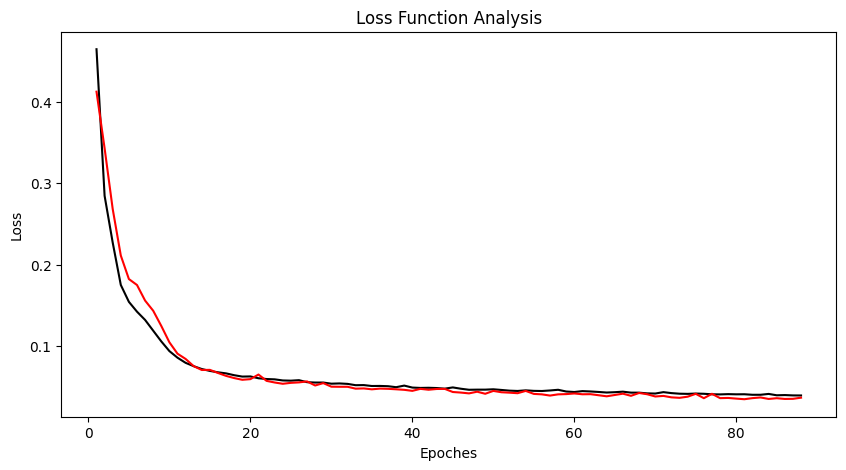

In [25]:
loss_function_analysis(history)

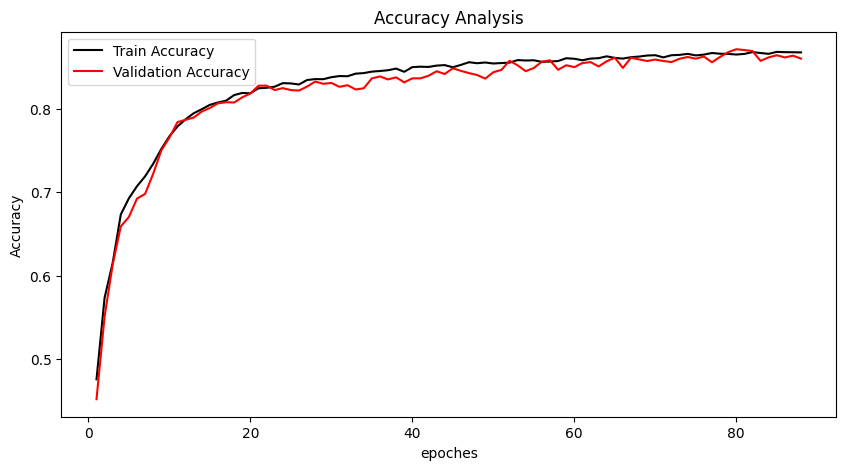

In [26]:
accuracy_analysis(history)

### Generate Reconstructions

The trained model reconstructs all combined training and validation windows using their feature values and encoded sensor IDs.


In [28]:
prediction = transformer_model.predict([train_data, sensor_ids_encoded])

253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


### Calculate Reconstruction Errors

The Mean Squared Error is calculated across the five features for every timestamp in each window. The result represents how strongly the reconstructed values differ from the original input values.


In [29]:
errors = np.mean(
    (train_data - prediction) ** 2,
    axis= 2
)

In [30]:
print(errors)

[[0.0193646  0.00405594 0.00147366 ... 0.00367177 0.00205079 0.01289093]
 [0.00801723 0.00220331 0.0016704  ... 0.00092303 0.00894302 0.00290984]
 [0.00477852 0.00567608 0.01084688 ... 0.006295   0.00102341 0.01716682]
 ...
 [0.02793068 0.01199623 0.03451029 ... 0.00736194 0.02538698 0.02500746]
 [0.00387535 0.00283162 0.04451526 ... 0.02948217 0.01359436 0.02404099]
 [0.01555702 0.00195186 0.05598474 ... 0.01524648 0.01220965 0.00210049]]


In [31]:
errors.shape

(8092, 24)

In [32]:
rows = []
for i in range(len(sensor_ids)):
    for j in range(window_size):
        rows.append({
            "SID": sensor_ids[i],
            "timestamp": window[i][j],
            "location": location[i],
            "error": errors[i][j]
        })
final_result = pd.DataFrame(rows)

In [33]:
final_result.head()

,SID,timestamp,location,error
0,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 01:00:00+00:00,Kurpark - Eingang Kurhaus,0.019365
1,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 02:00:00+00:00,Kurpark - Eingang Kurhaus,0.004056
2,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 03:00:00+00:00,Kurpark - Eingang Kurhaus,0.001474
3,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 04:00:00+00:00,Kurpark - Eingang Kurhaus,0.067245
4,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 05:00:00+00:00,Kurpark - Eingang Kurhaus,0.006502


In [34]:
sensors = list(final_result['SID'].unique())

### Visualize the Error Distribution

This function displays the distribution of reconstruction errors for a selected sensor. The histogram helps identify the typical error range and unusually high errors.


In [35]:
def error_distribution(sensor):
    data = final_result[final_result['SID'] == sensor]
    location = data['location'].iloc[0]
    plt.figure(figsize = (10,6))
    sns.histplot(data = data['error'], bins = 20)
    plt.title(f"Error Data Distribution in {location}")
    plt.xlabel("Error")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
    return 0

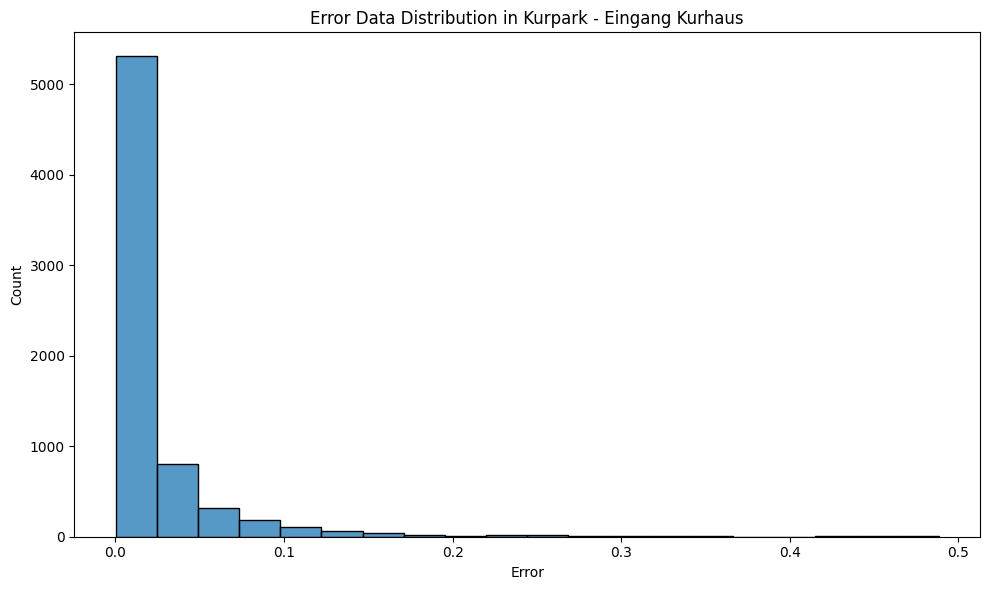

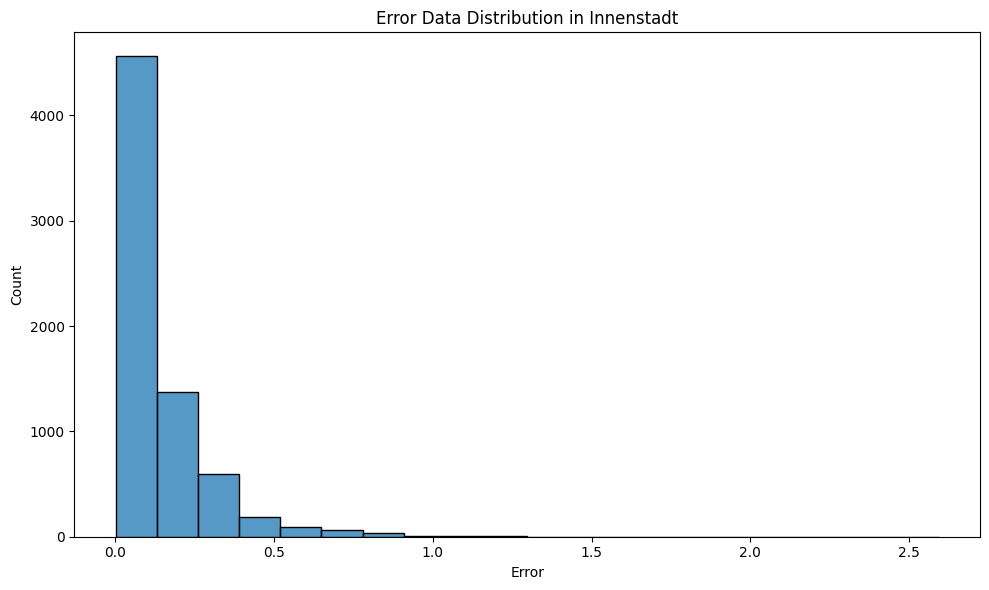

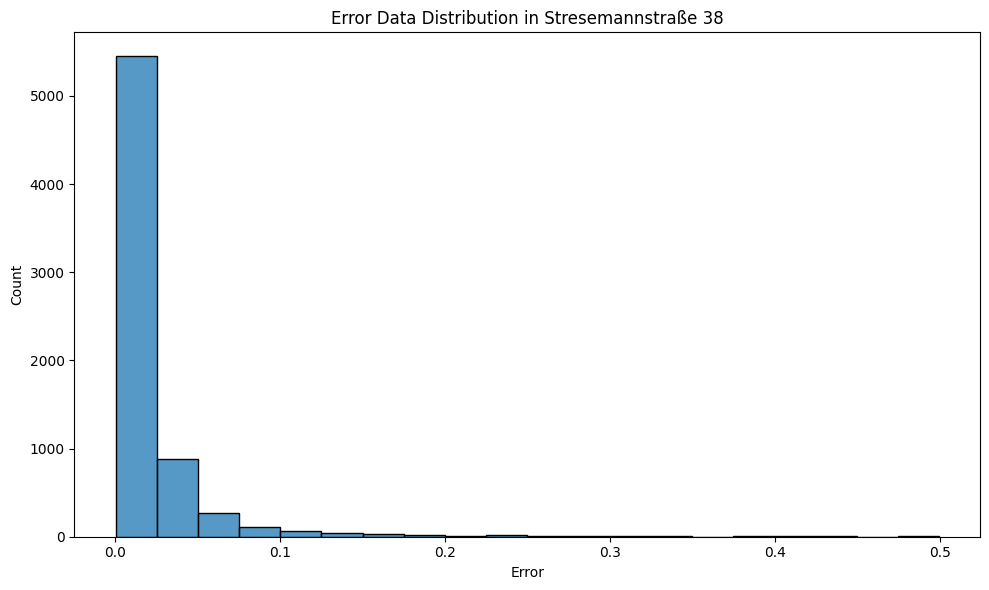

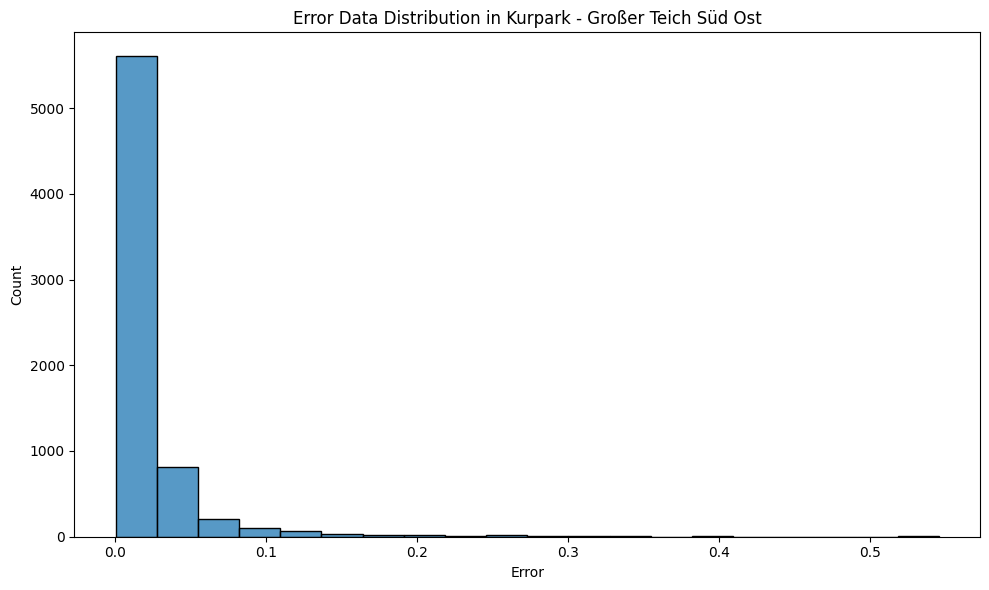

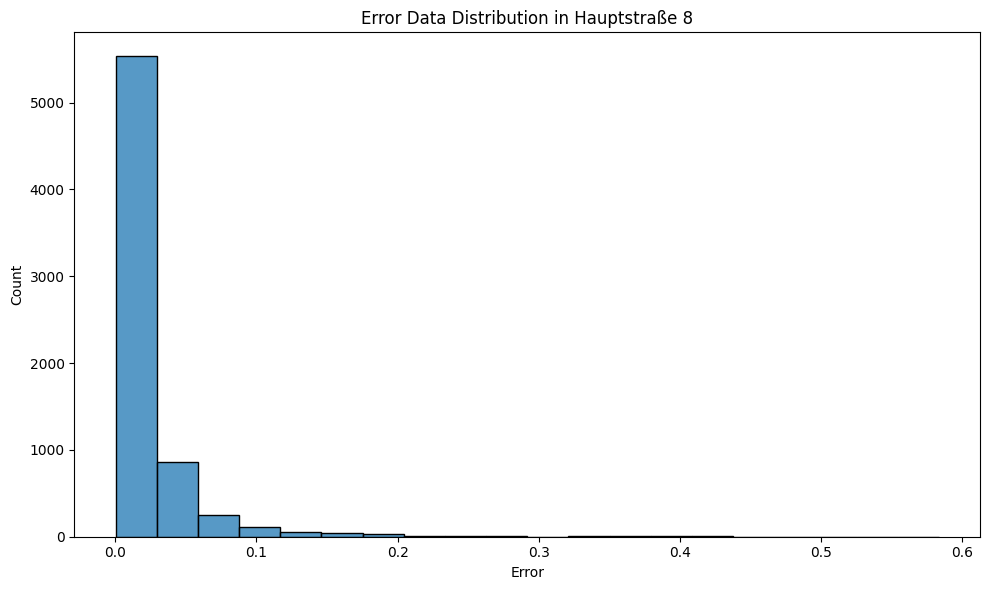

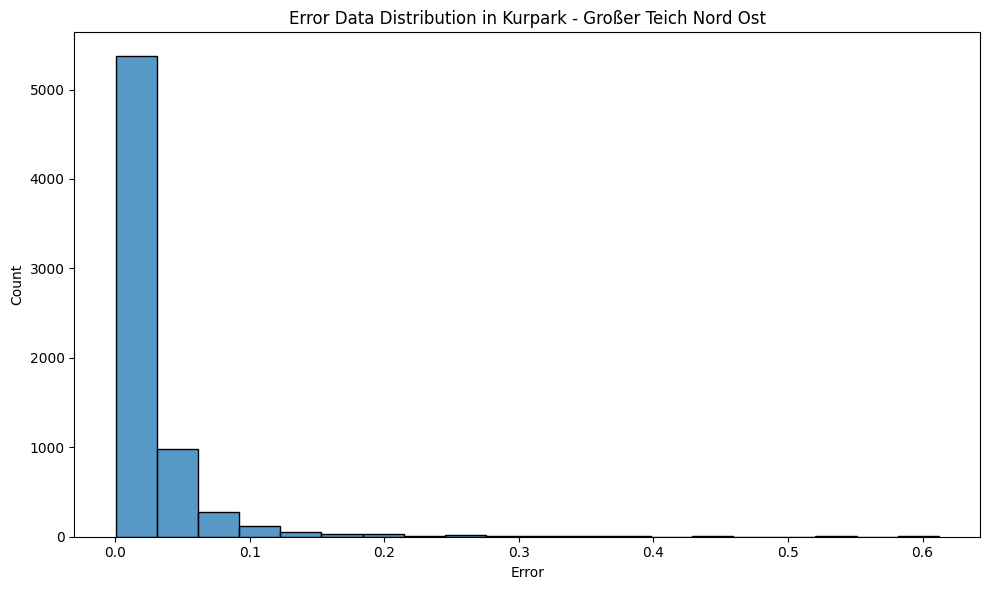

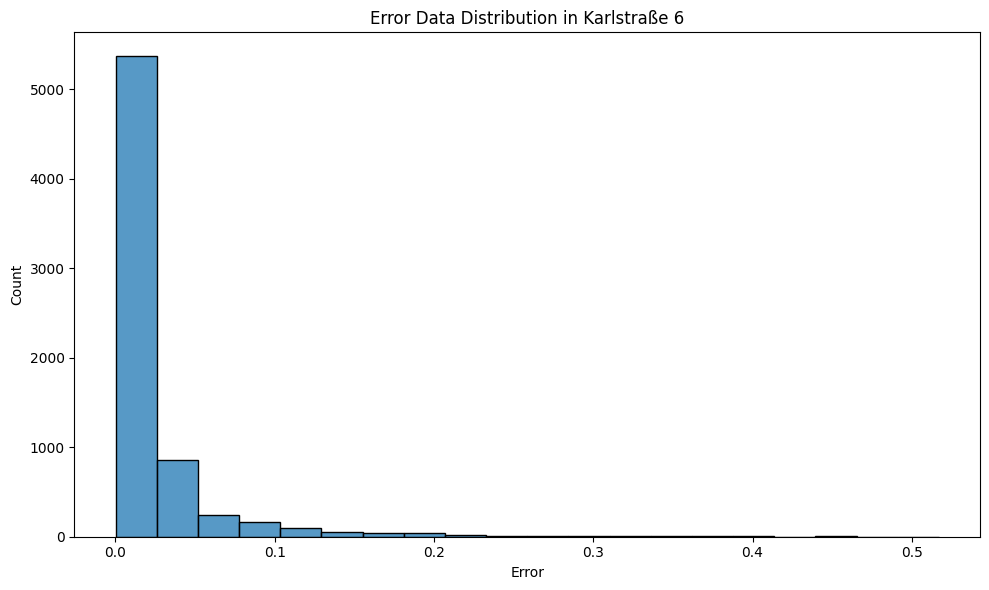

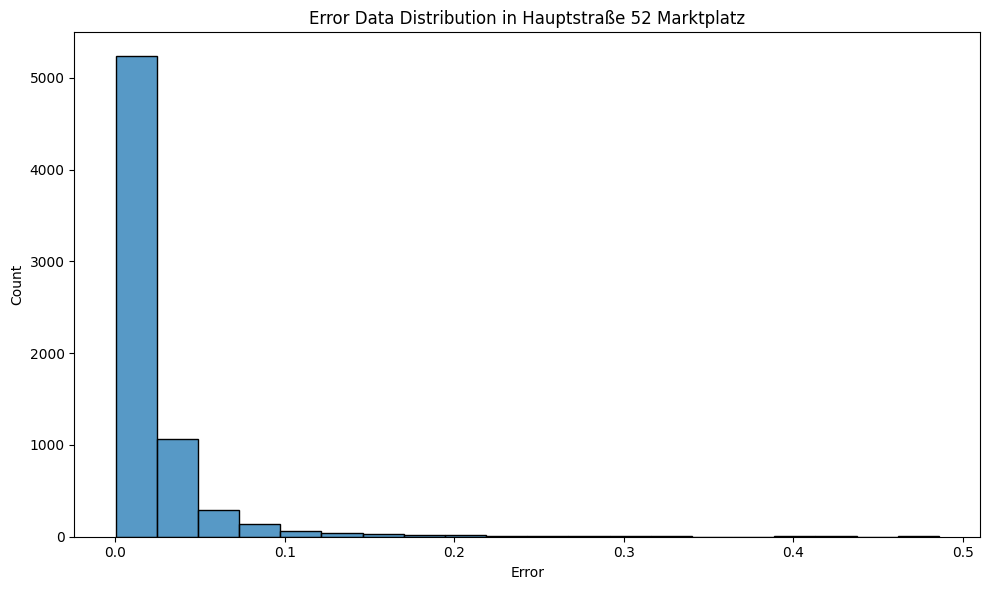

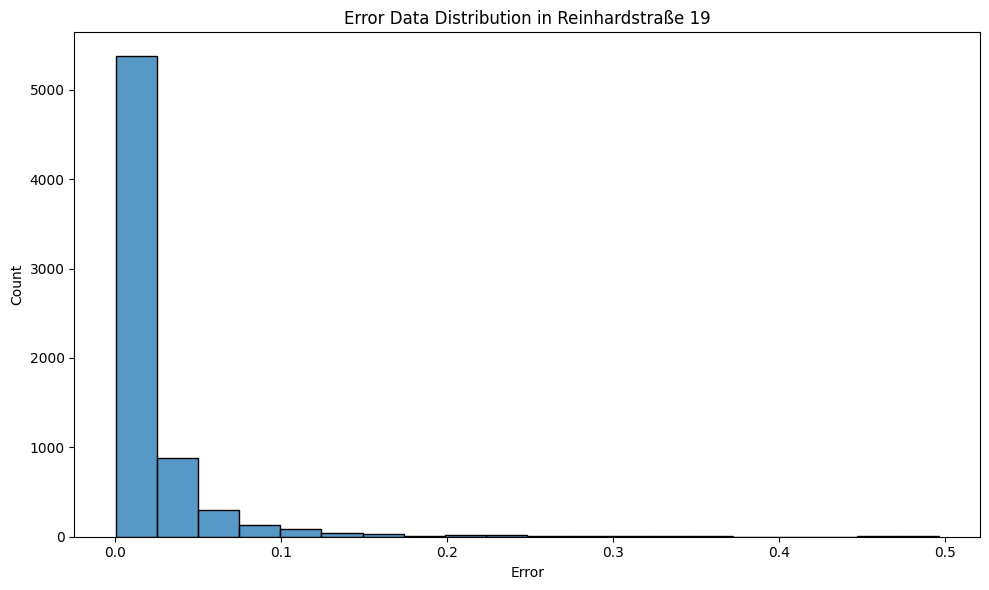

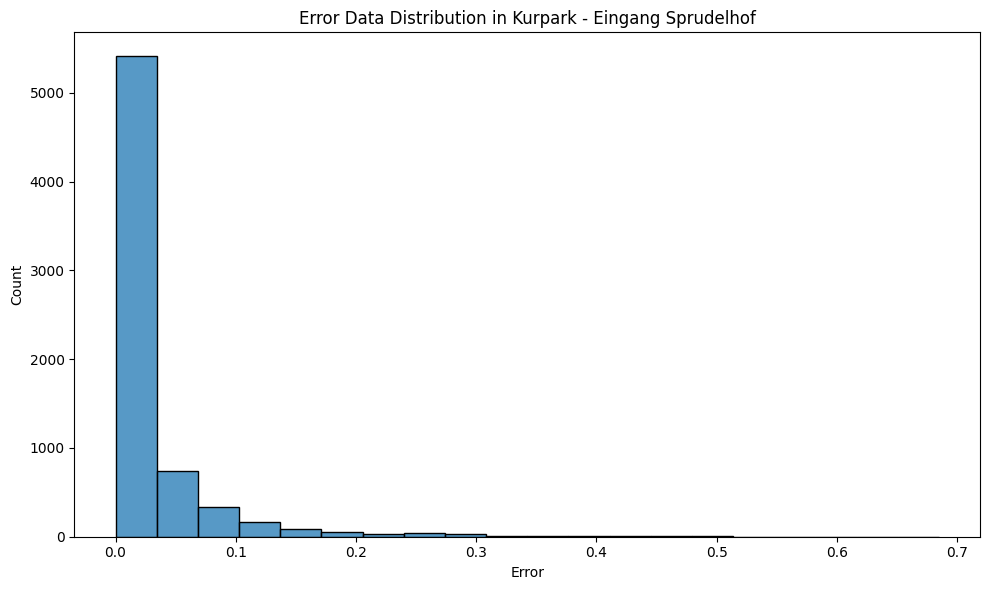

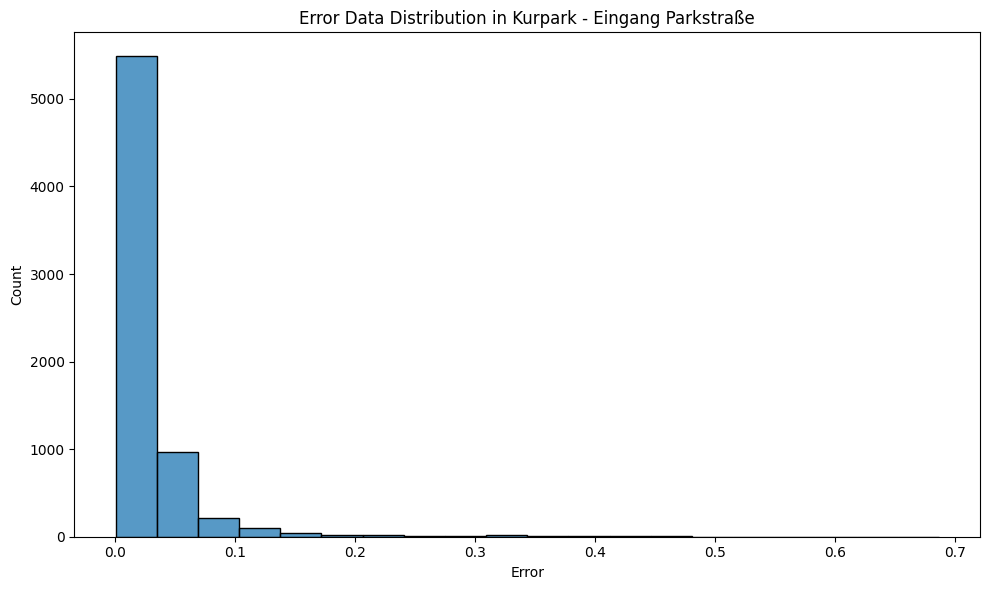

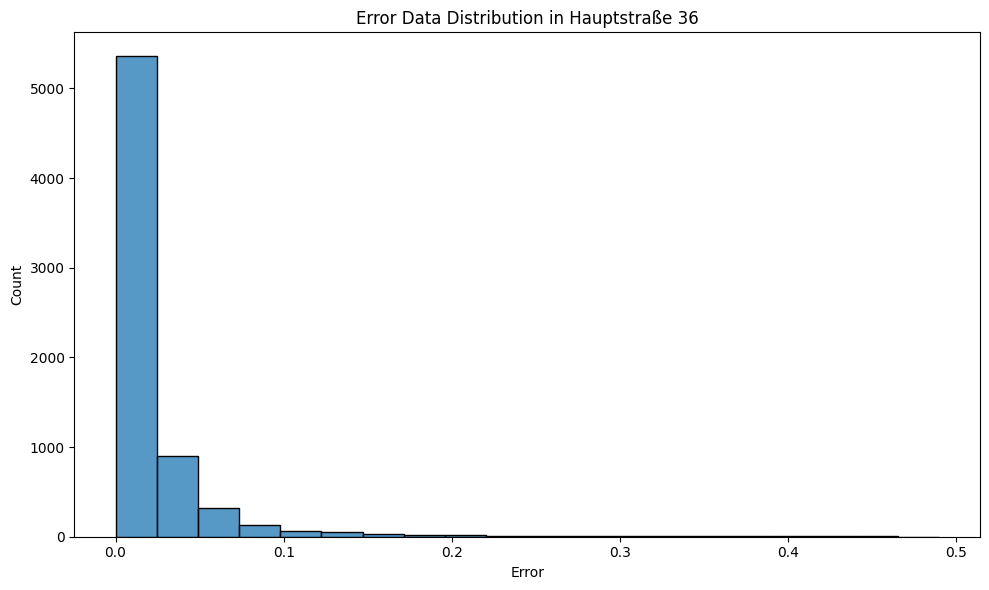

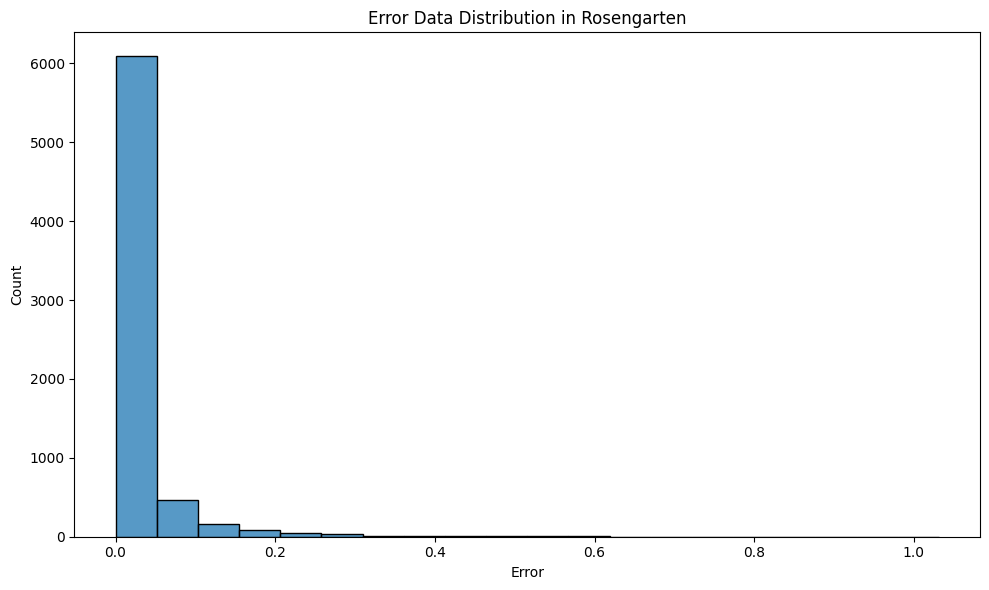

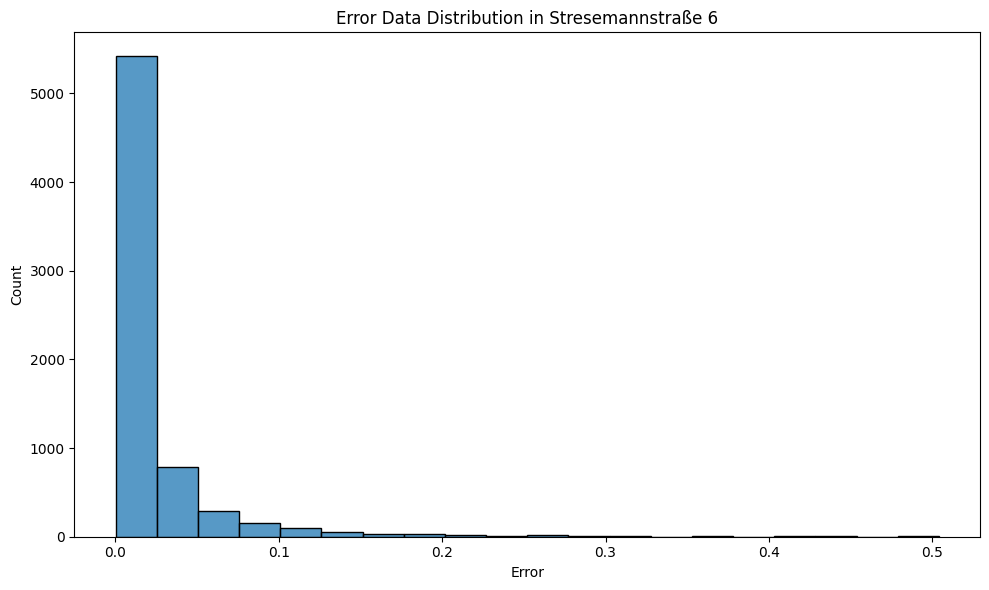

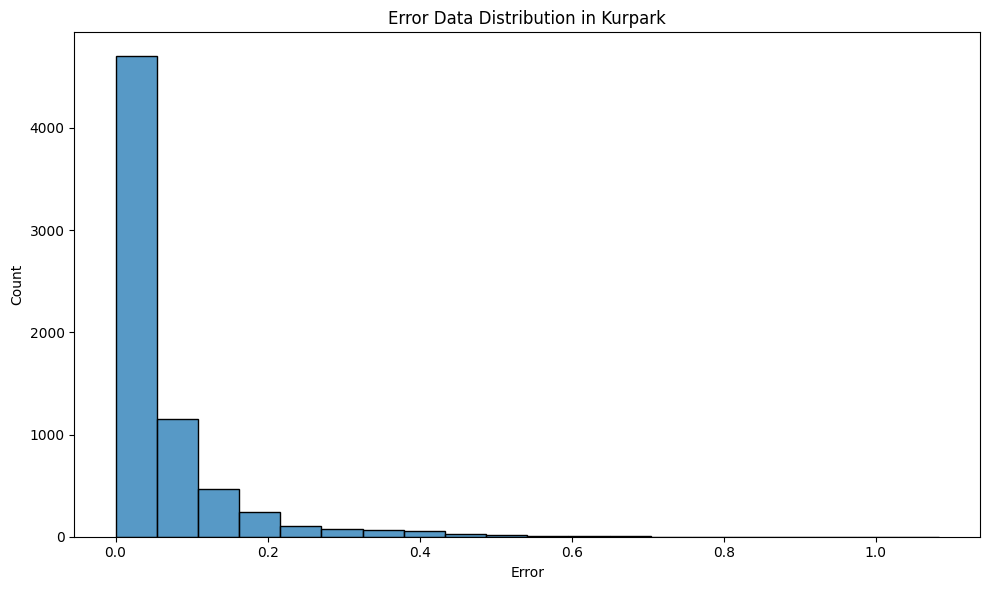

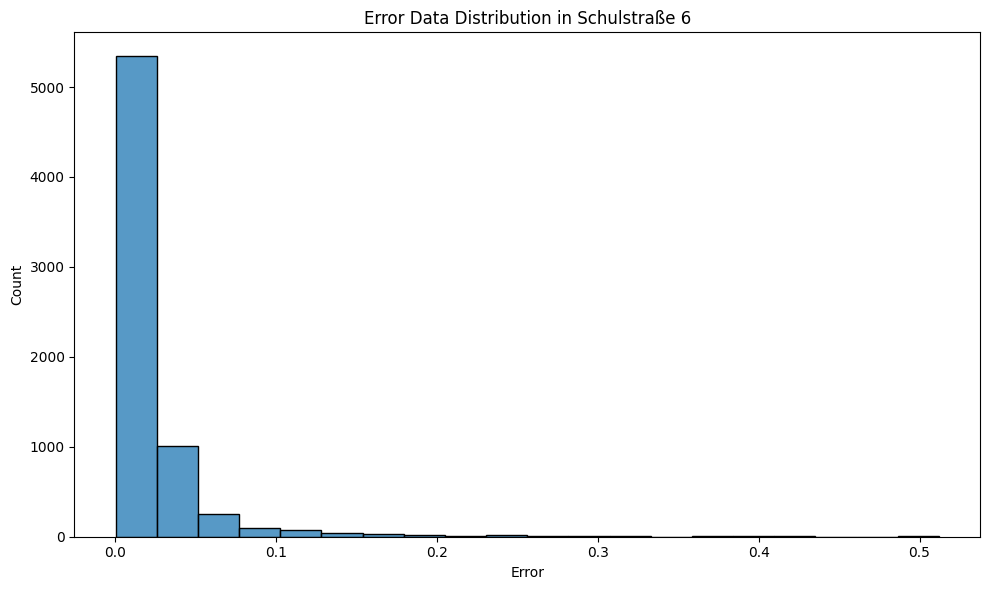

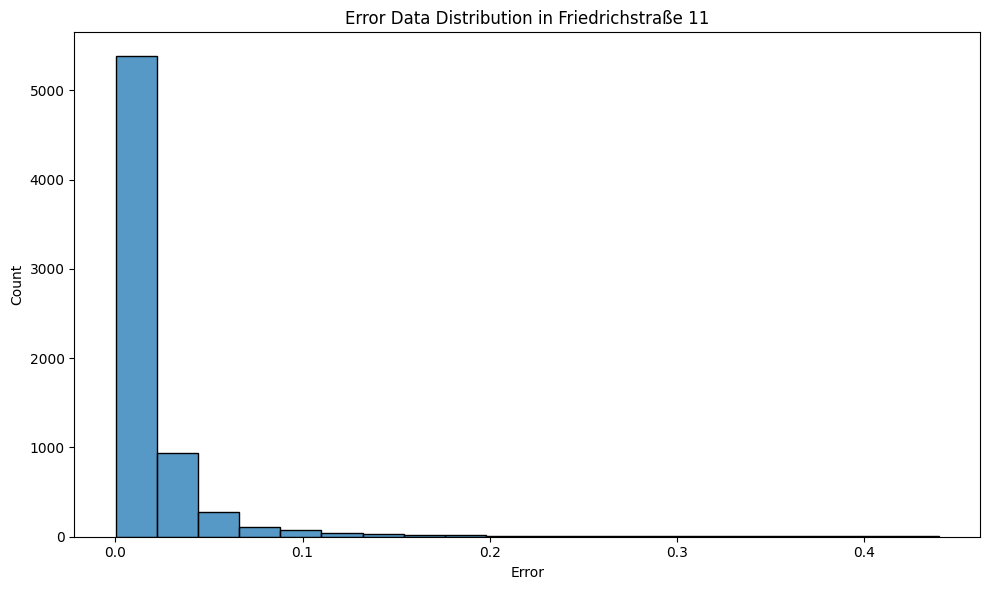

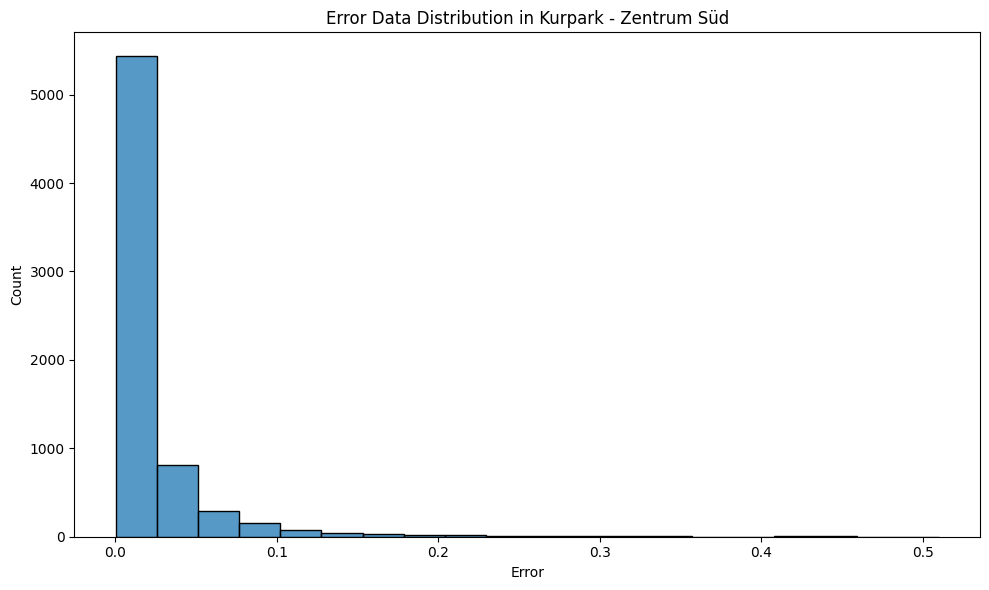

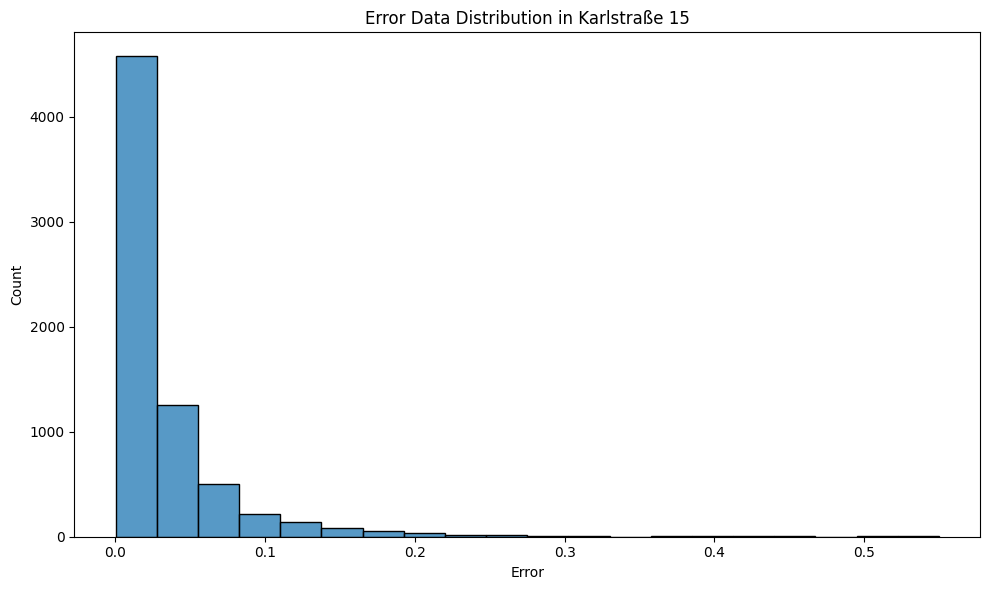

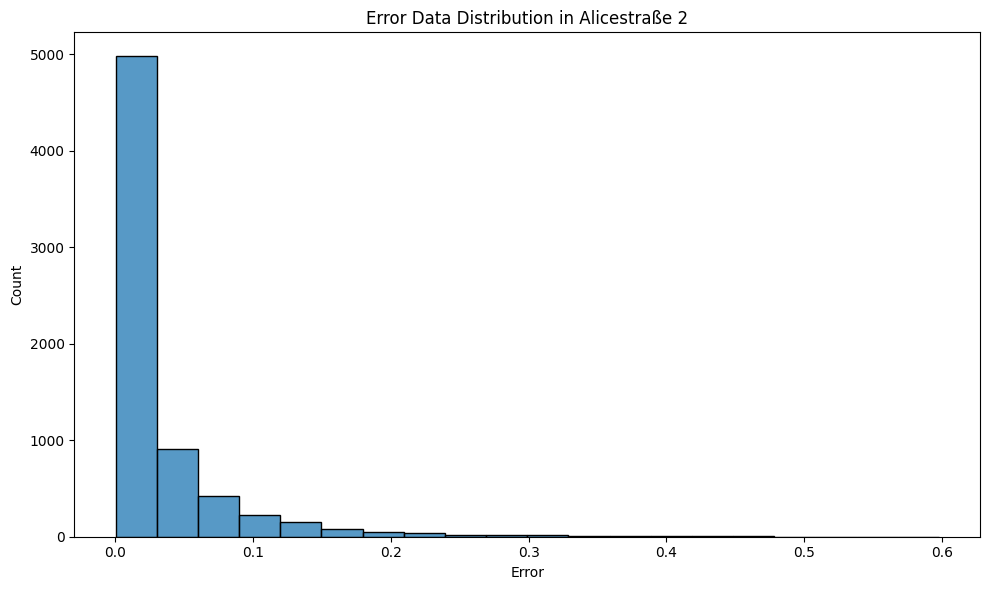

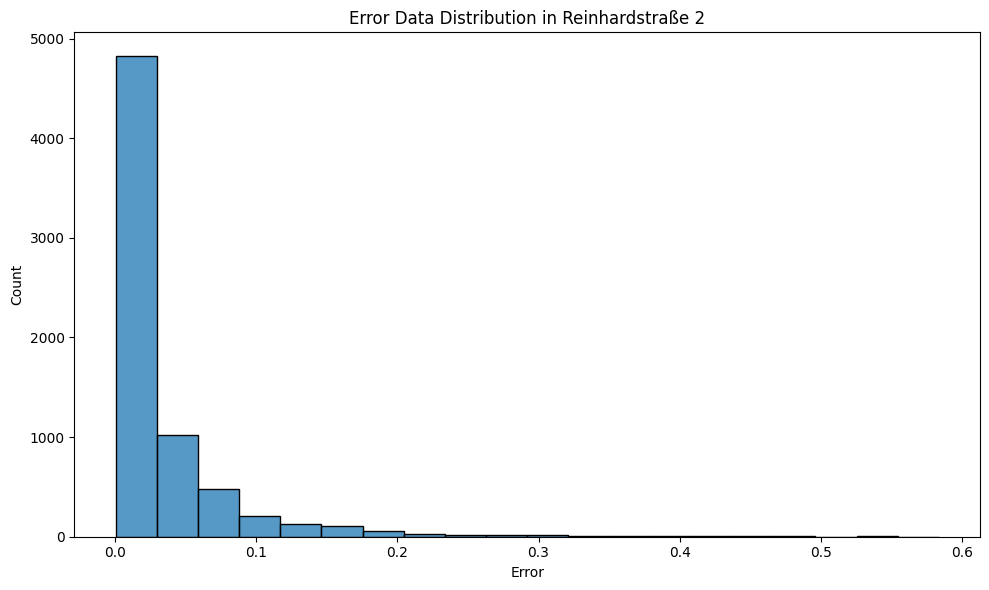

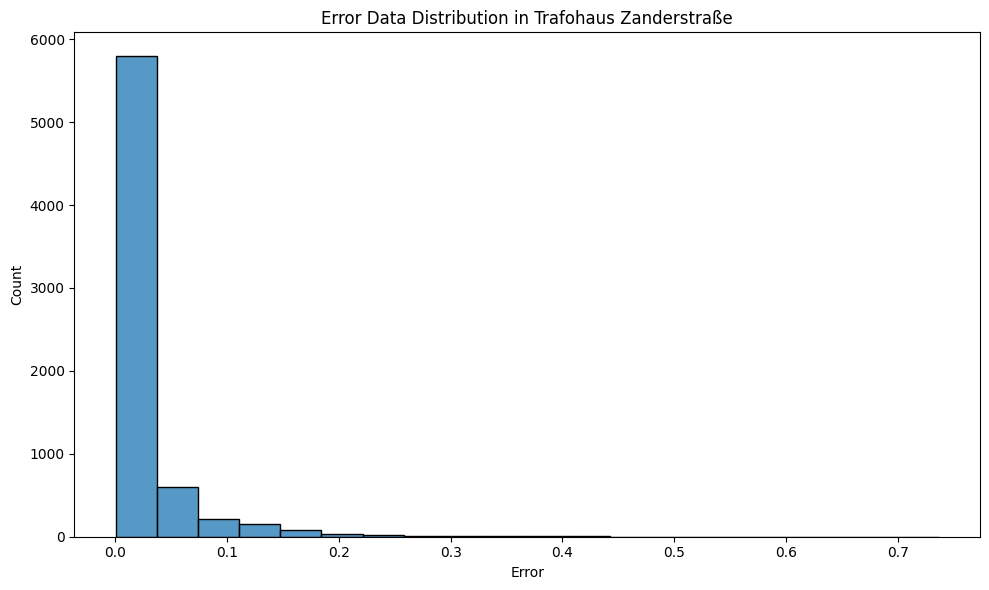

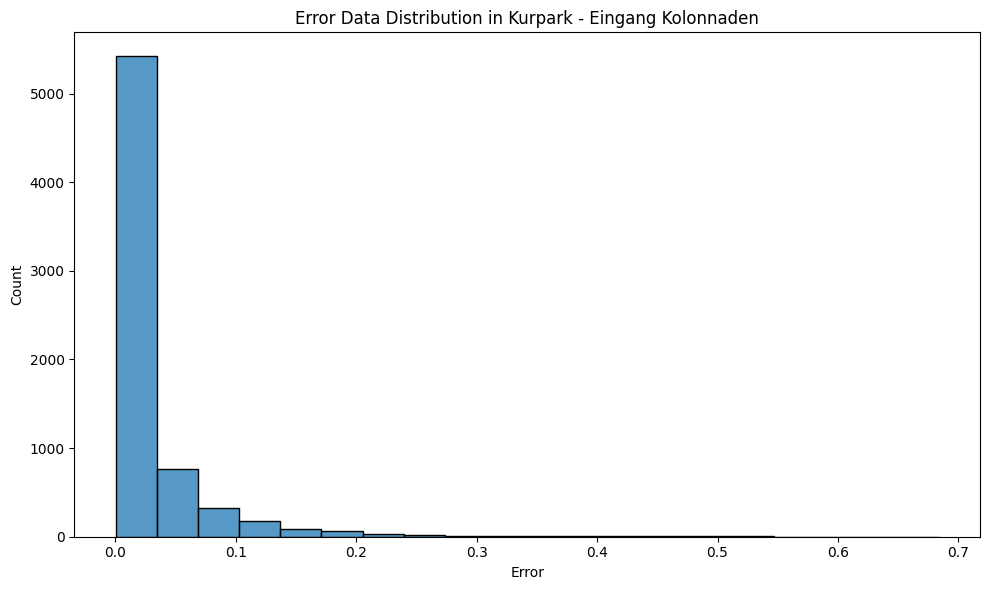

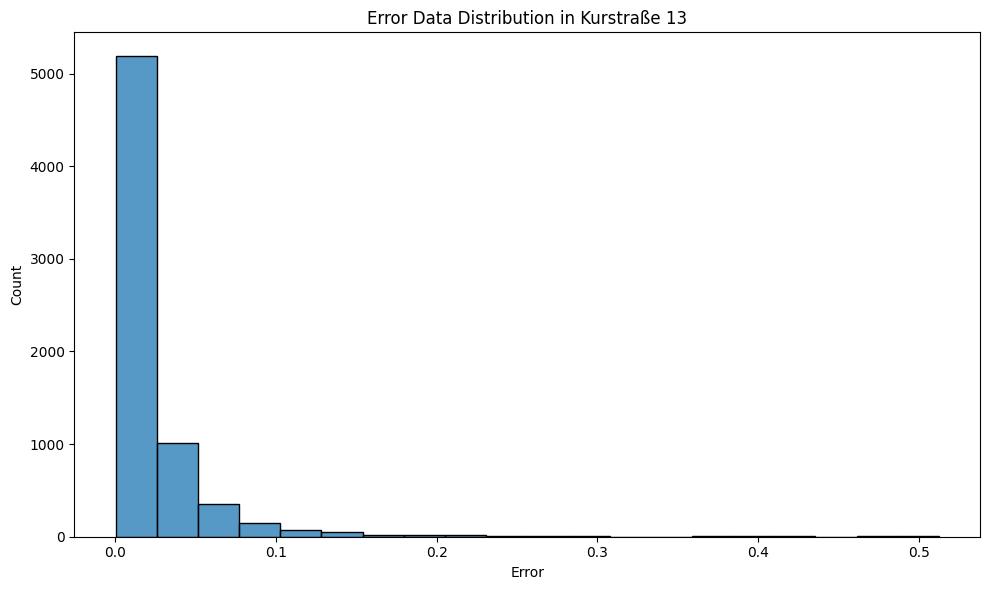

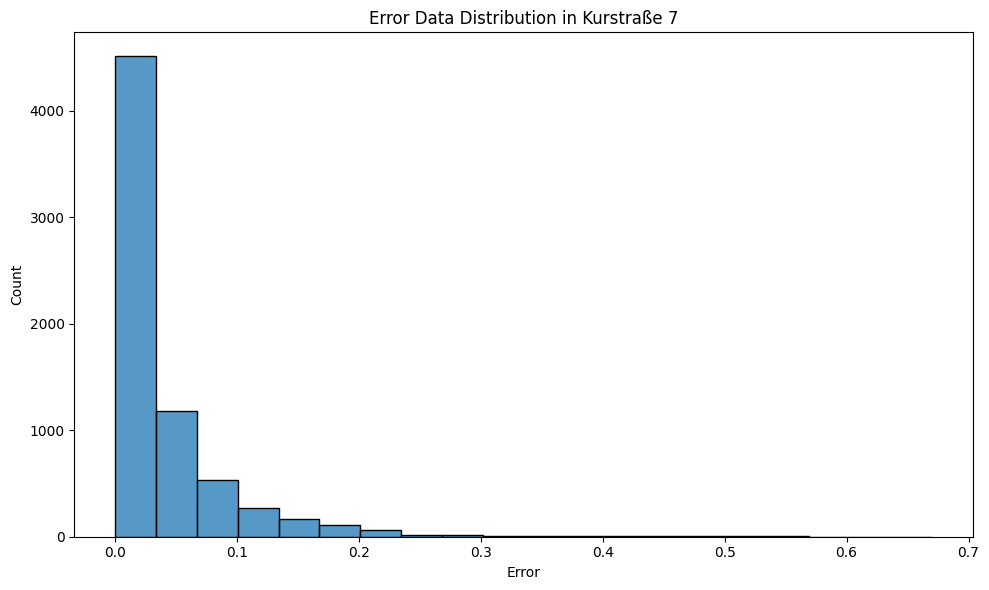

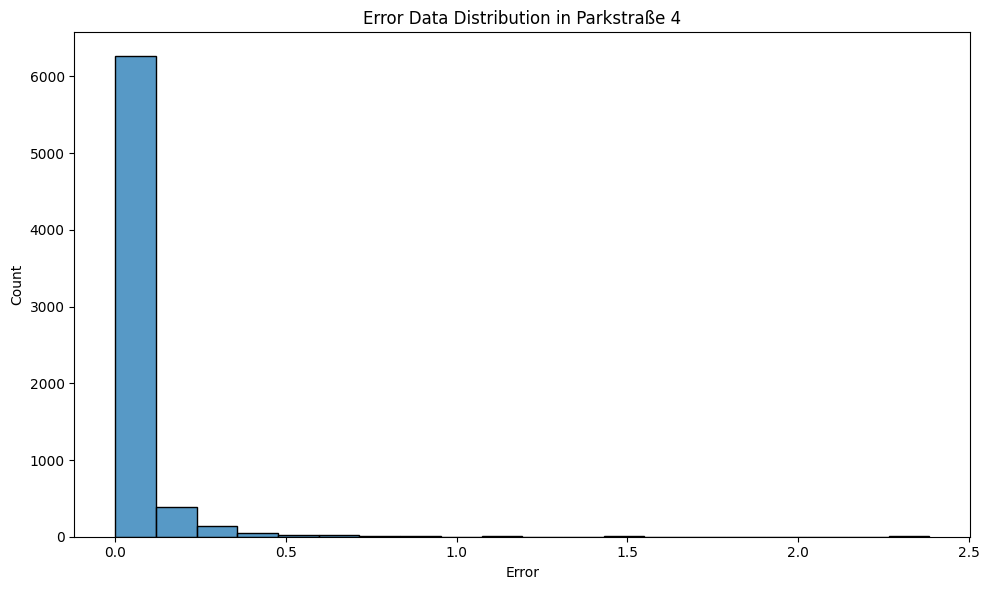

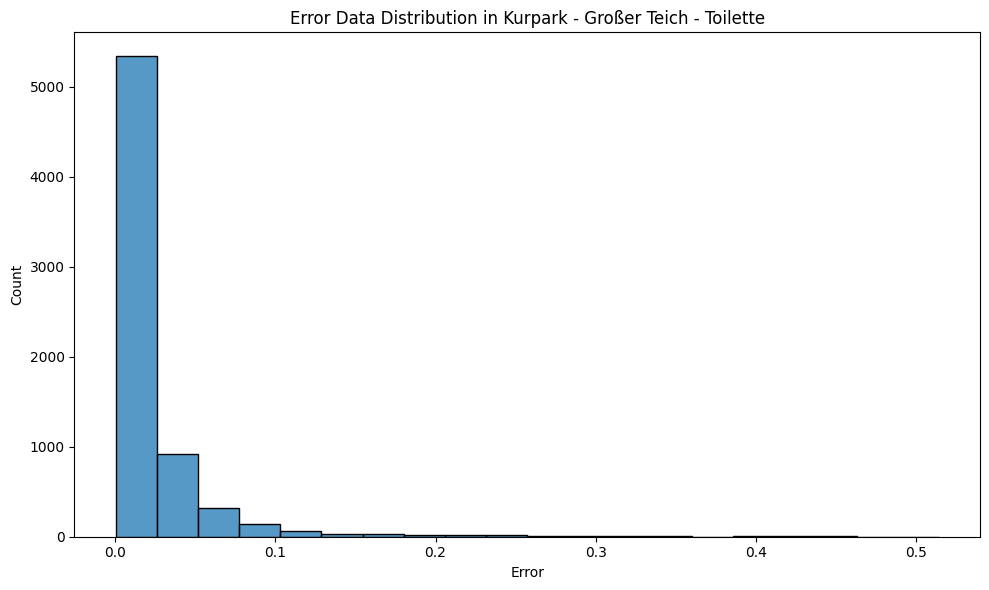

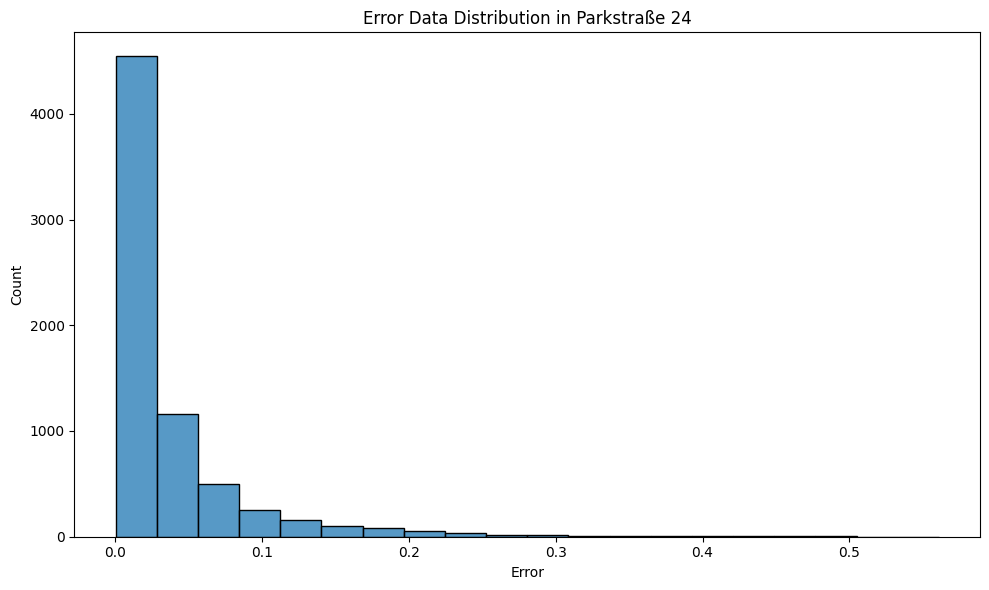

In [36]:
for sensor in sensors:
    error_distribution(sensor)

### Calculate the Anomaly Threshold

The threshold is calculated using the Interquartile Range (`IQR`). An error above \(Q3 + 1.5 * IQR\) is considered a potential anomaly.


In [37]:
def iqr_threshold(errors, factor = 1.5):
    Q1 = np.percentile(errors, 25)
    Q3 = np.percentile(errors, 75)

    IQR = Q3 - Q1

    threshold = Q3 + factor * IQR

    return threshold

### Visualize Detected Anomalies

The reconstruction errors from overlapping windows are averaged for each timestamp. Errors above the sensor-specific IQR threshold are marked as anomalies and displayed together with the error curve and threshold line.


In [38]:
def anomaly_plot(sensor_id):
    sensor_data = final_result[final_result['SID'] == sensor_id]
    sensor_data['timestamp'] = pd.to_datetime(sensor_data['timestamp'])
    sensor_data = sensor_data.sort_values('timestamp')
    location = sensor_data['location'].iloc[0]

    agg = sensor_data.groupby('timestamp', as_index=False)['error'].mean()
    threshold = iqr_threshold(agg['error'])

    anomalies = agg[agg['error'] > threshold]
    count_anomaly = len(anomalies)
    
    plt.figure(figsize=(16,6))

    #Reconstruction Error Line
    plt.plot(agg['timestamp'], 
             agg['error'],
            color='steelblue',
            linewidth=1.5,
            marker='o',
            markersize=3,
            label='Reconstruction Error'
            )
    #Threshold Line
    plt.axhline(threshold,
                color='red',
                linestyle='--',
                label= f'Threshold: {threshold}',
                linewidth = 2
                )
     #Anamoly points
    plt.scatter(
        anomalies['timestamp'],
        anomalies['error'],
        color='crimson',
        s=70,
        marker='o',
        edgecolors='black',
        linewidths=0.8,
        label=f'Anomalies ({count_anomaly})',
        zorder=5
    )   
    plt.xlabel('Date')
    plt.ylabel('Reconstruction Errors')
    plt.title(f'Anomaly on Sensor at {location}')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

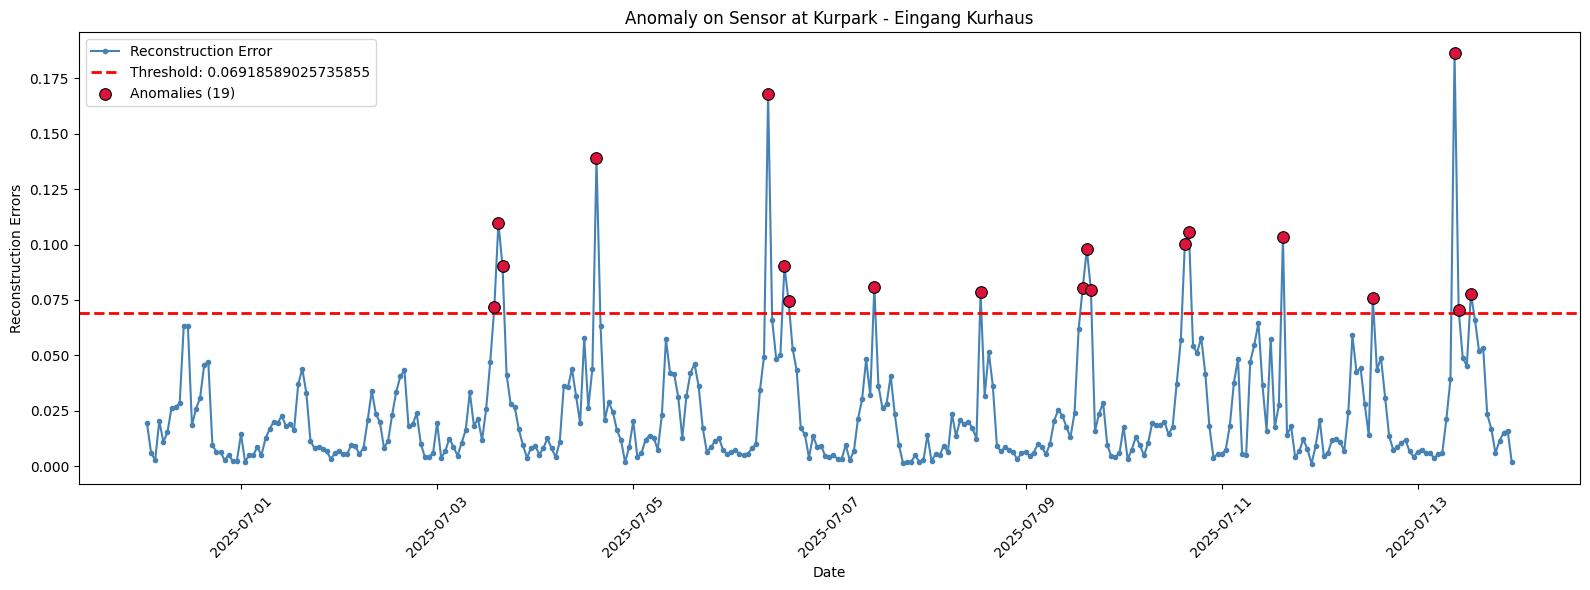

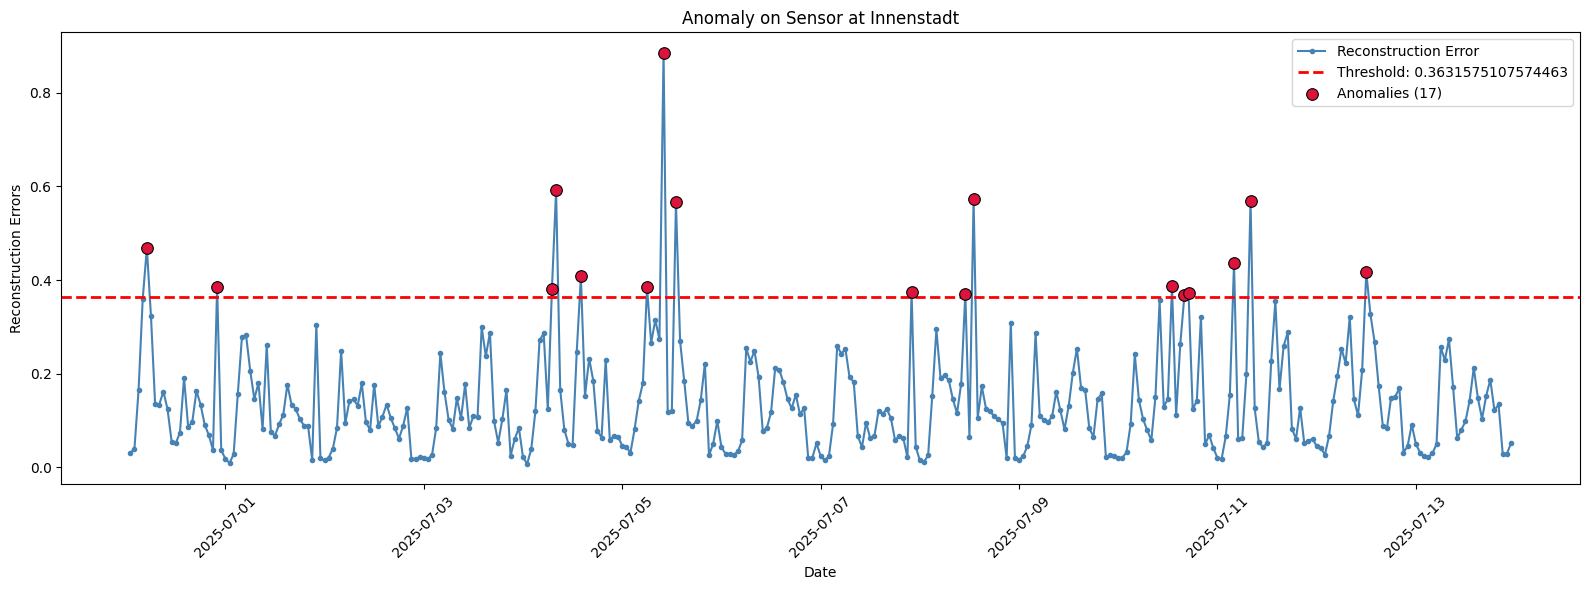

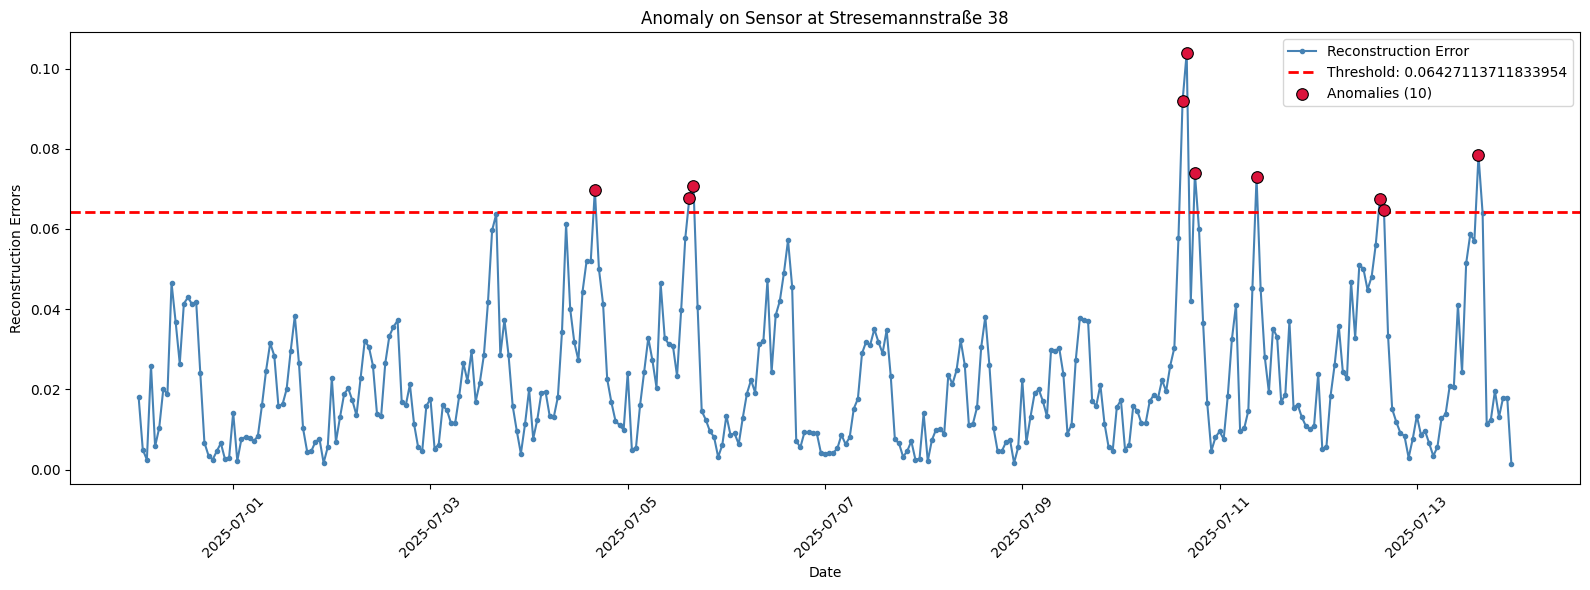

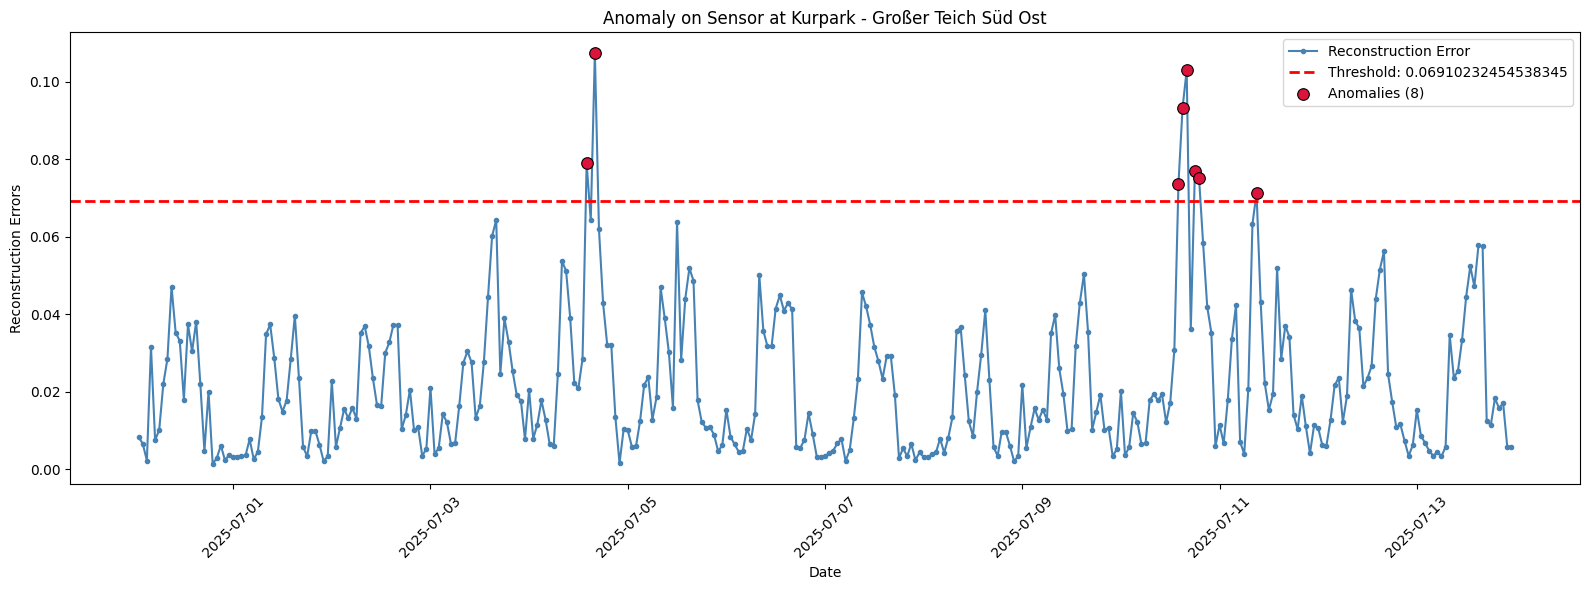

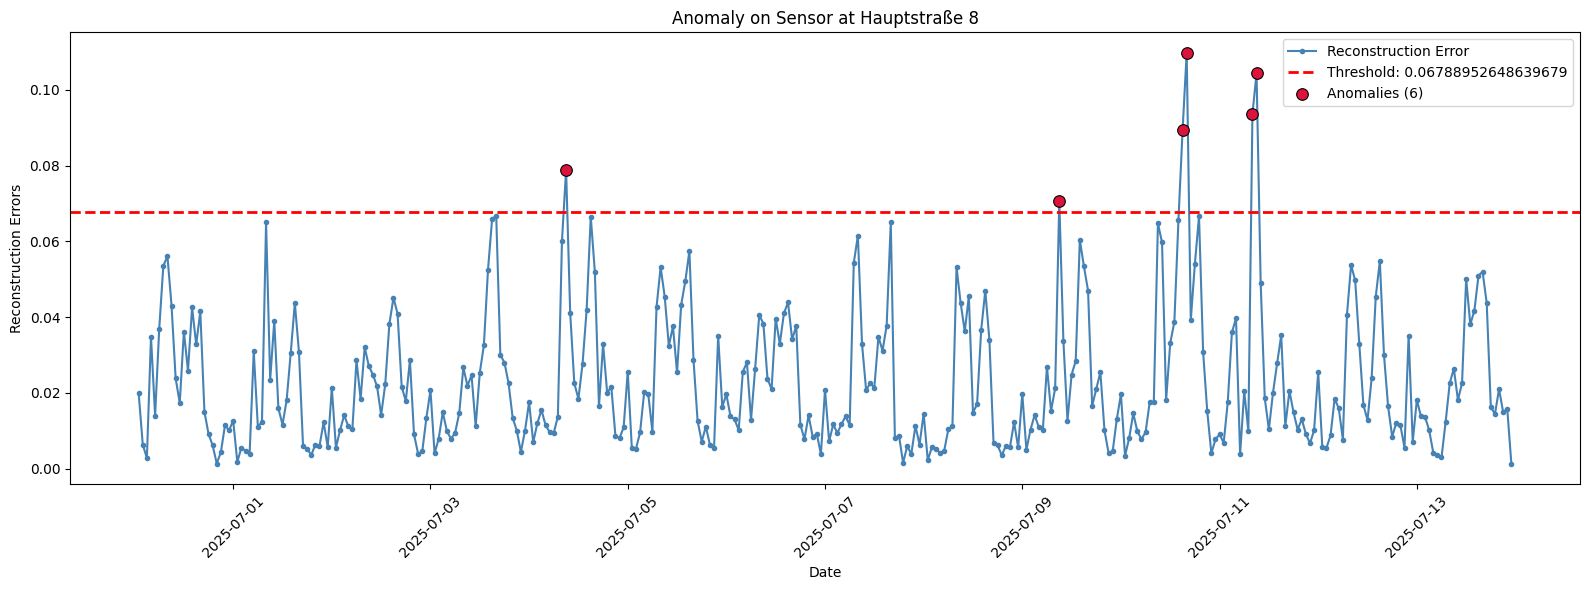

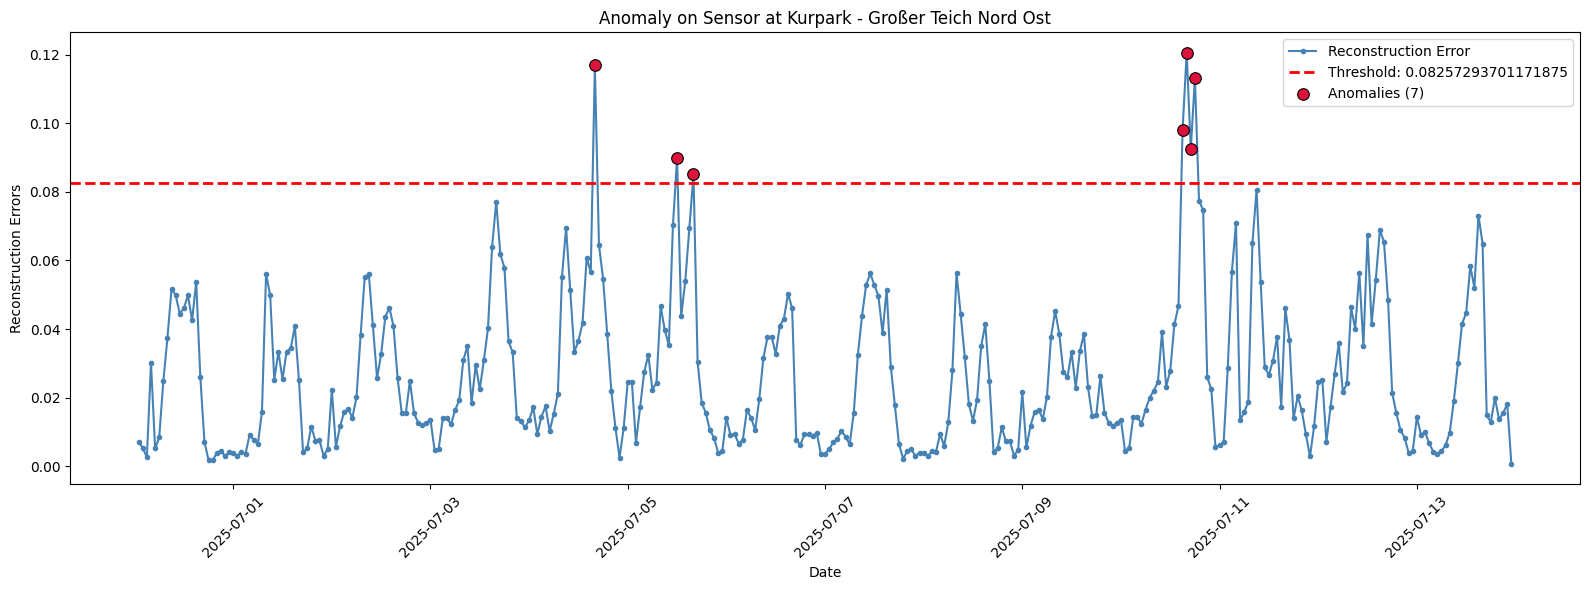

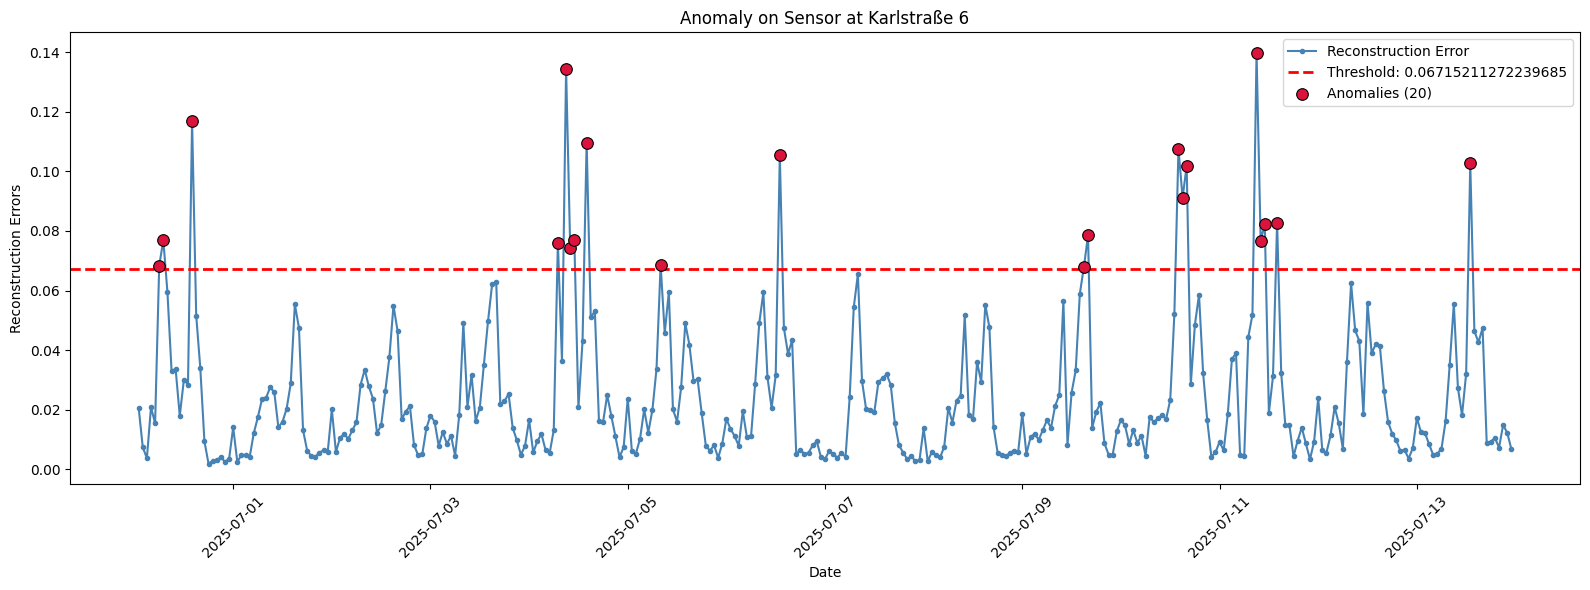

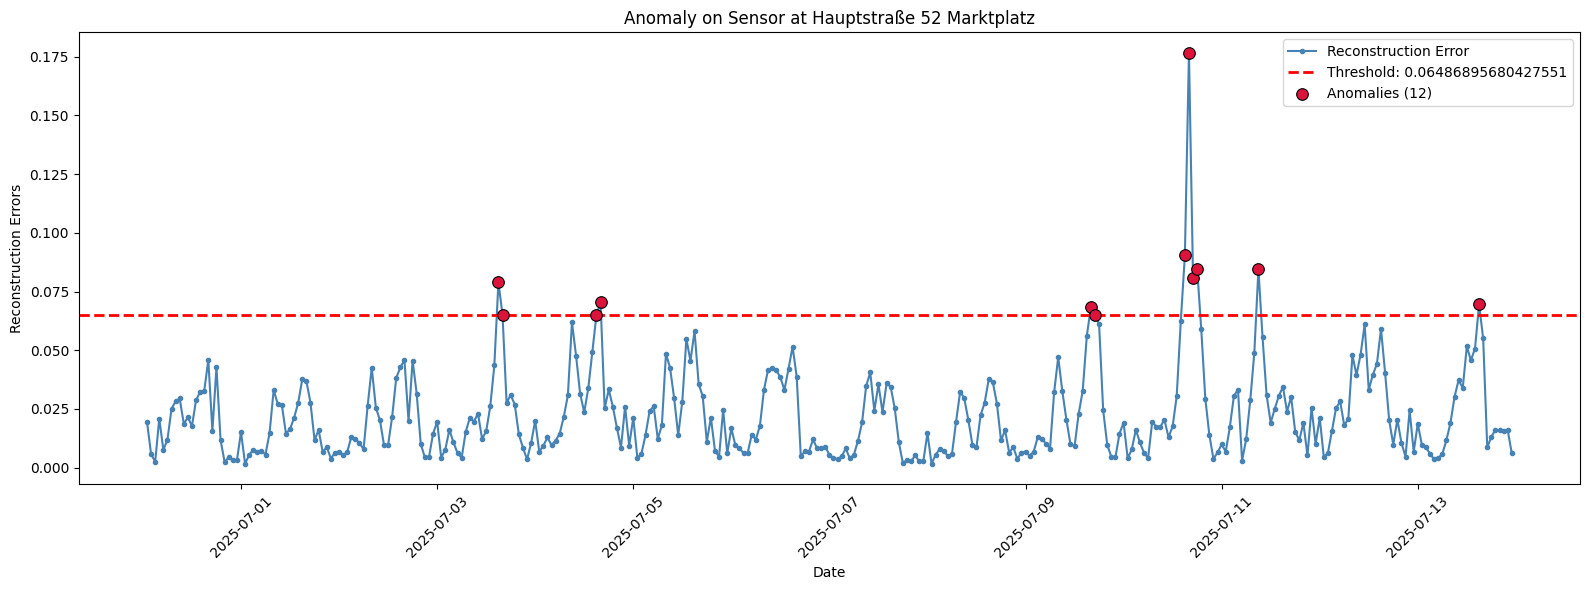

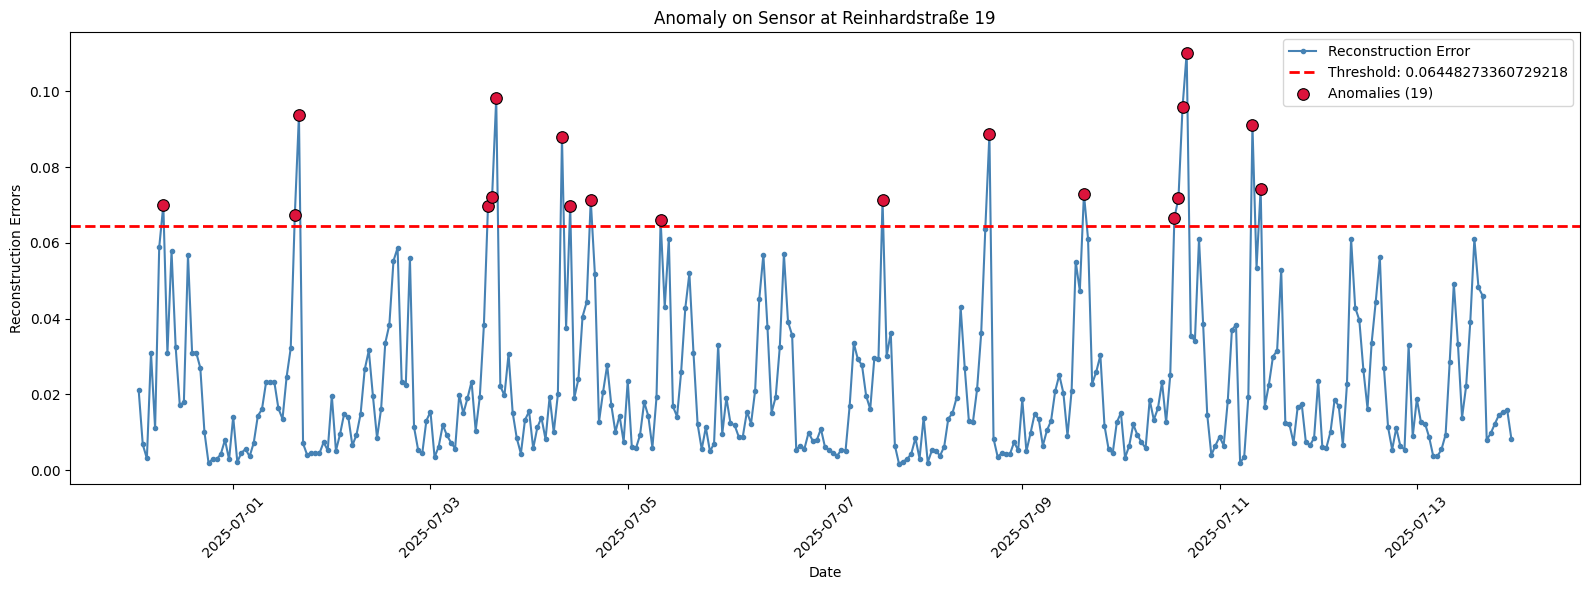

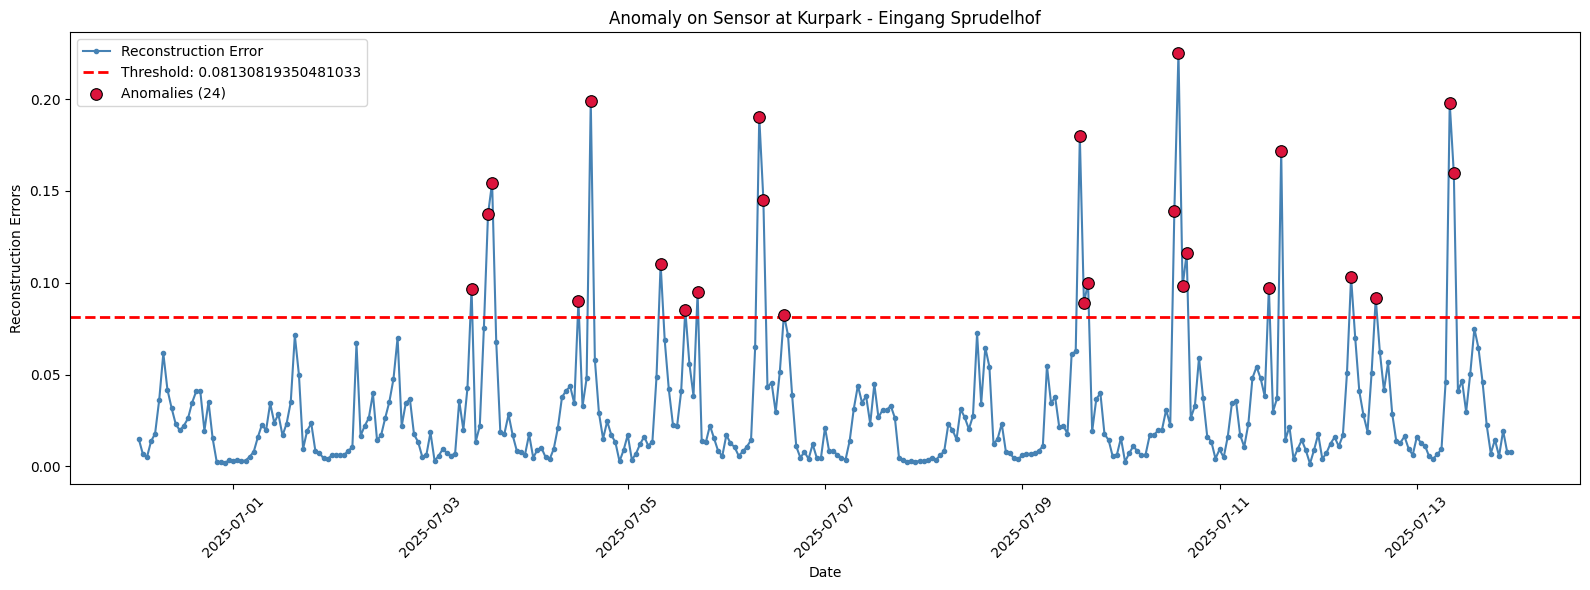

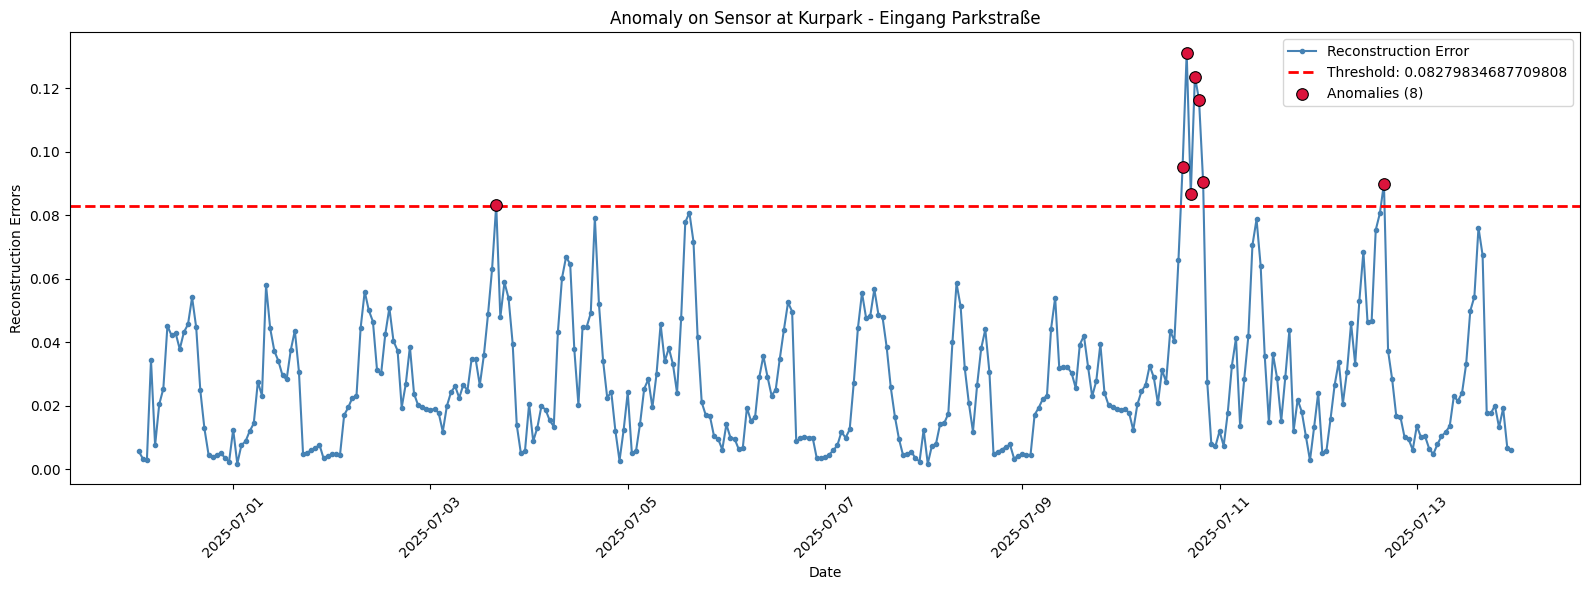

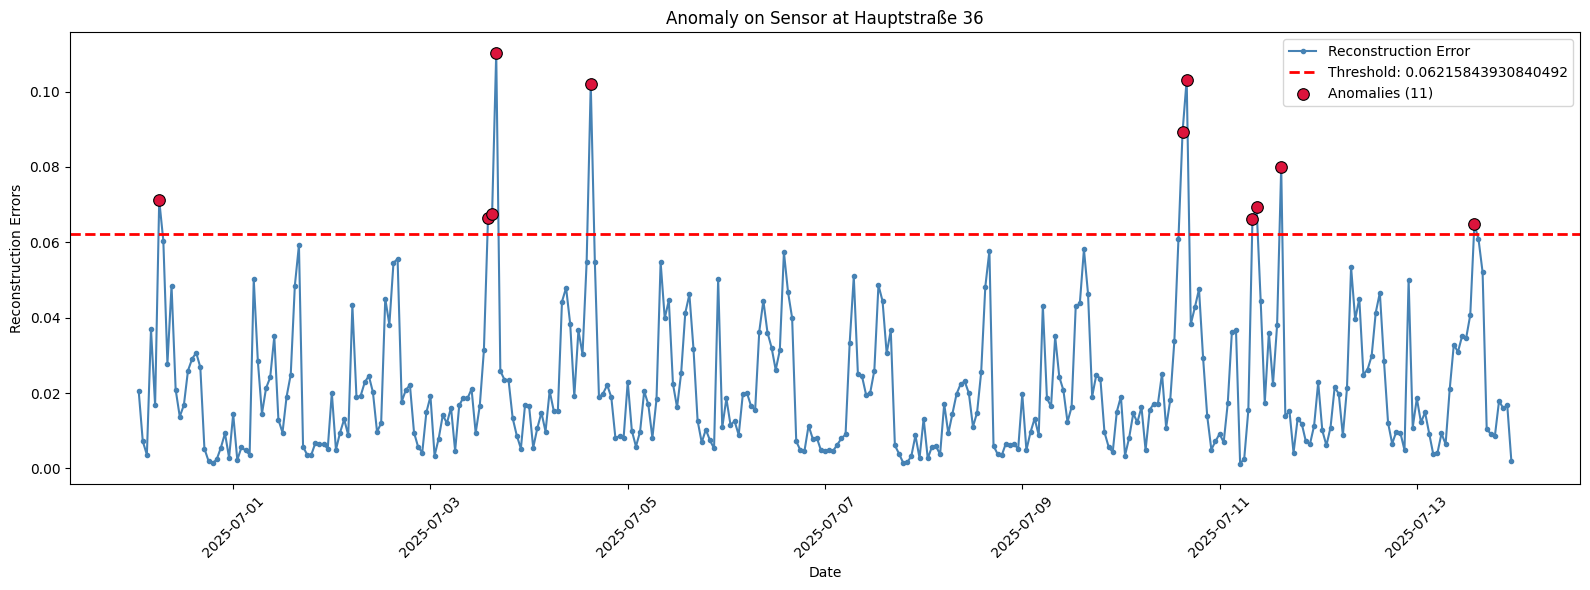

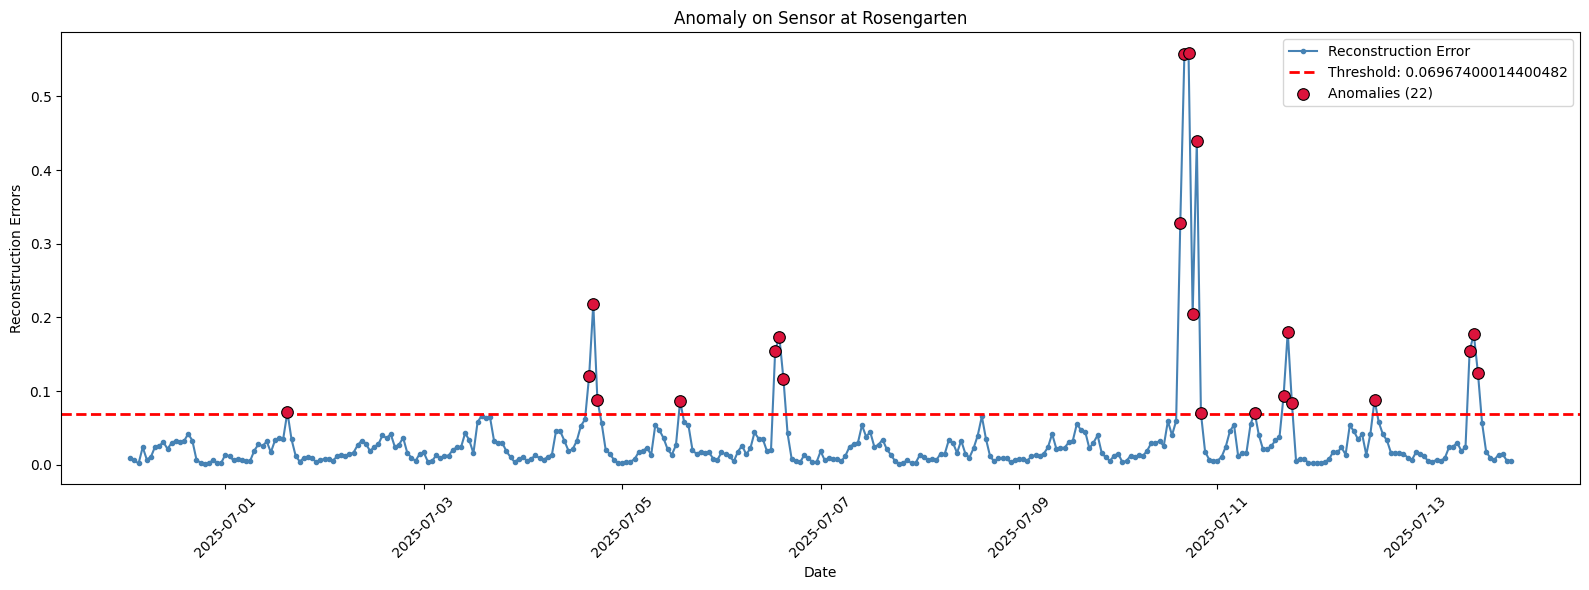

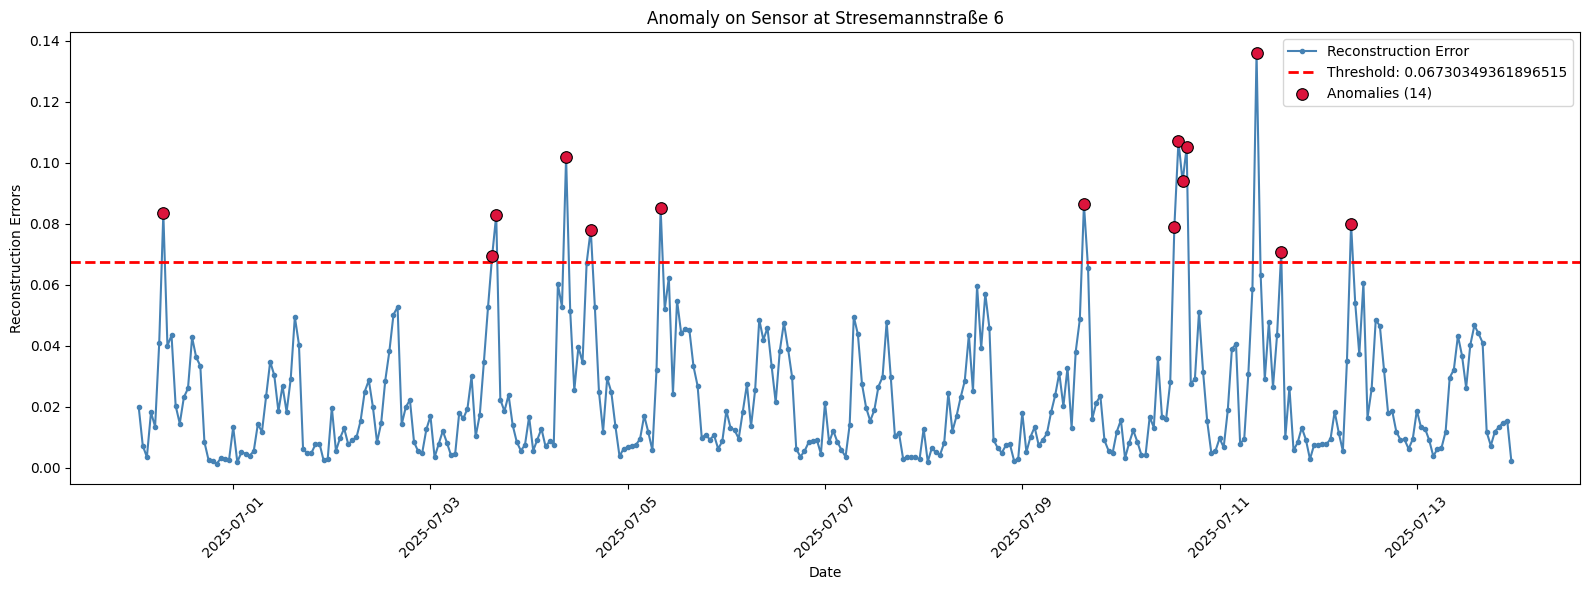

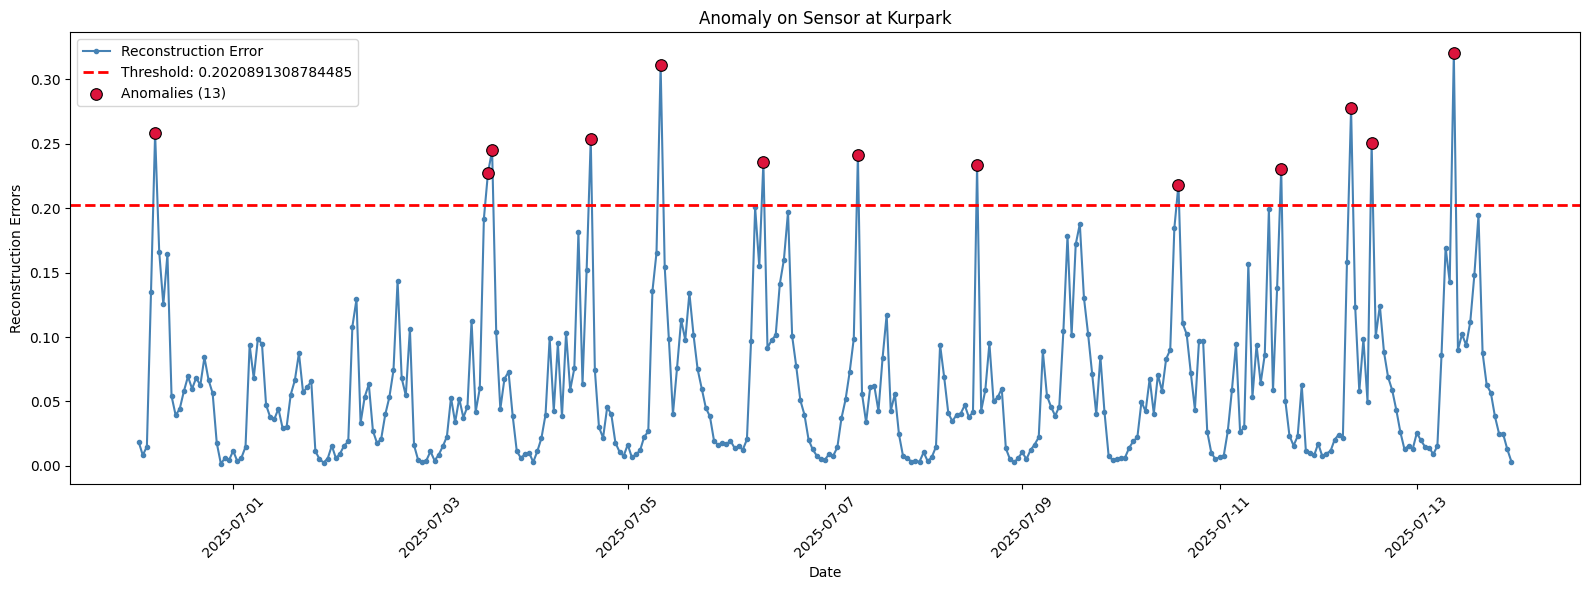

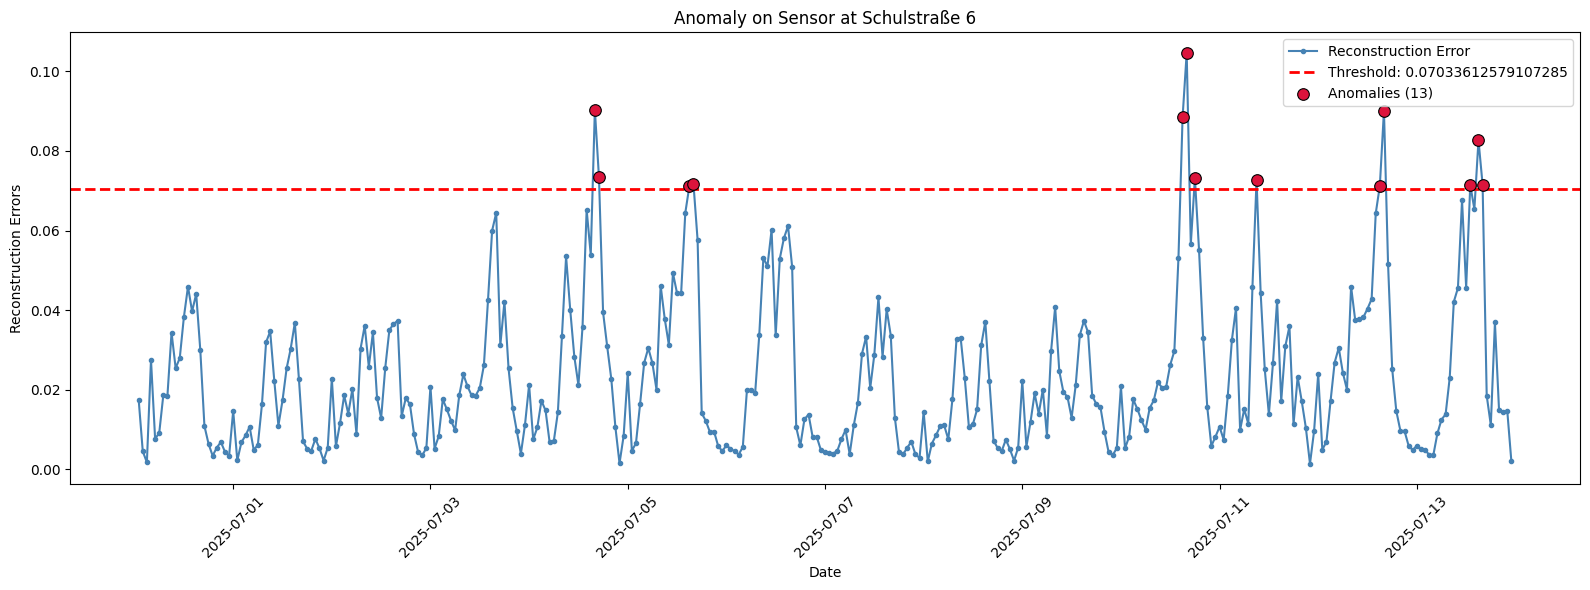

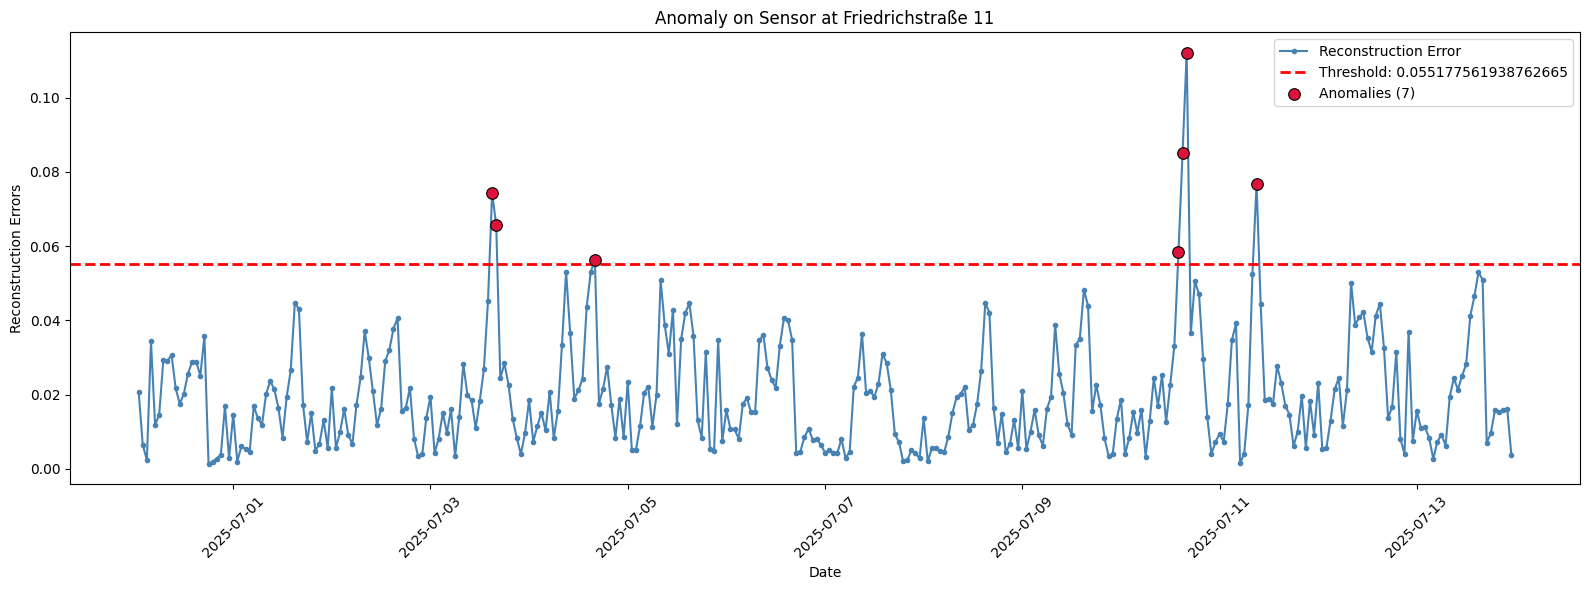

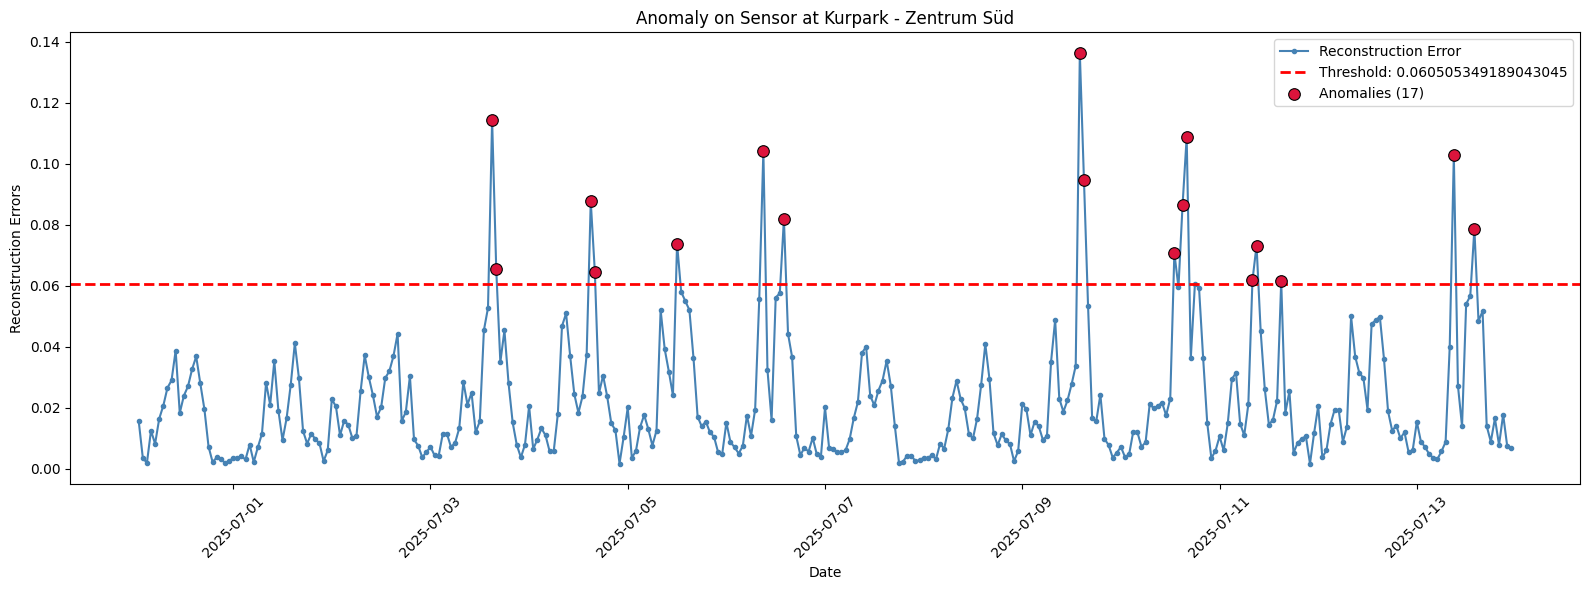

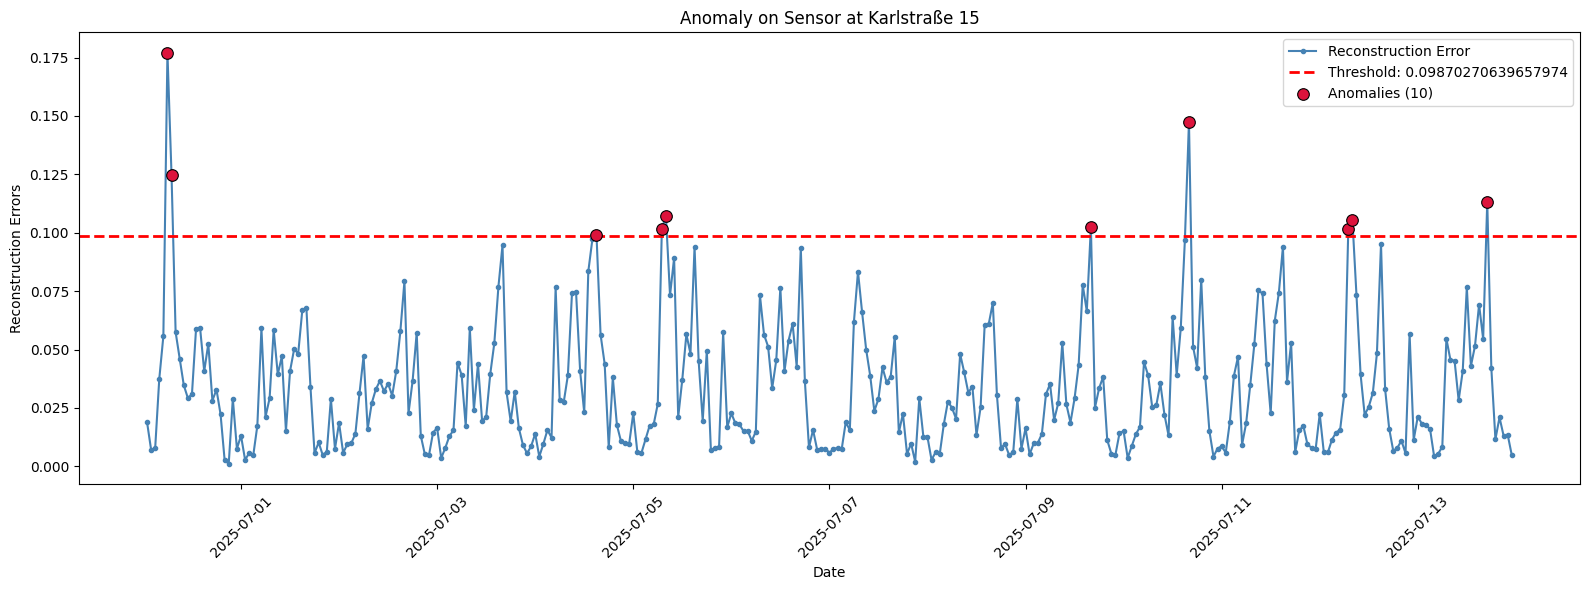

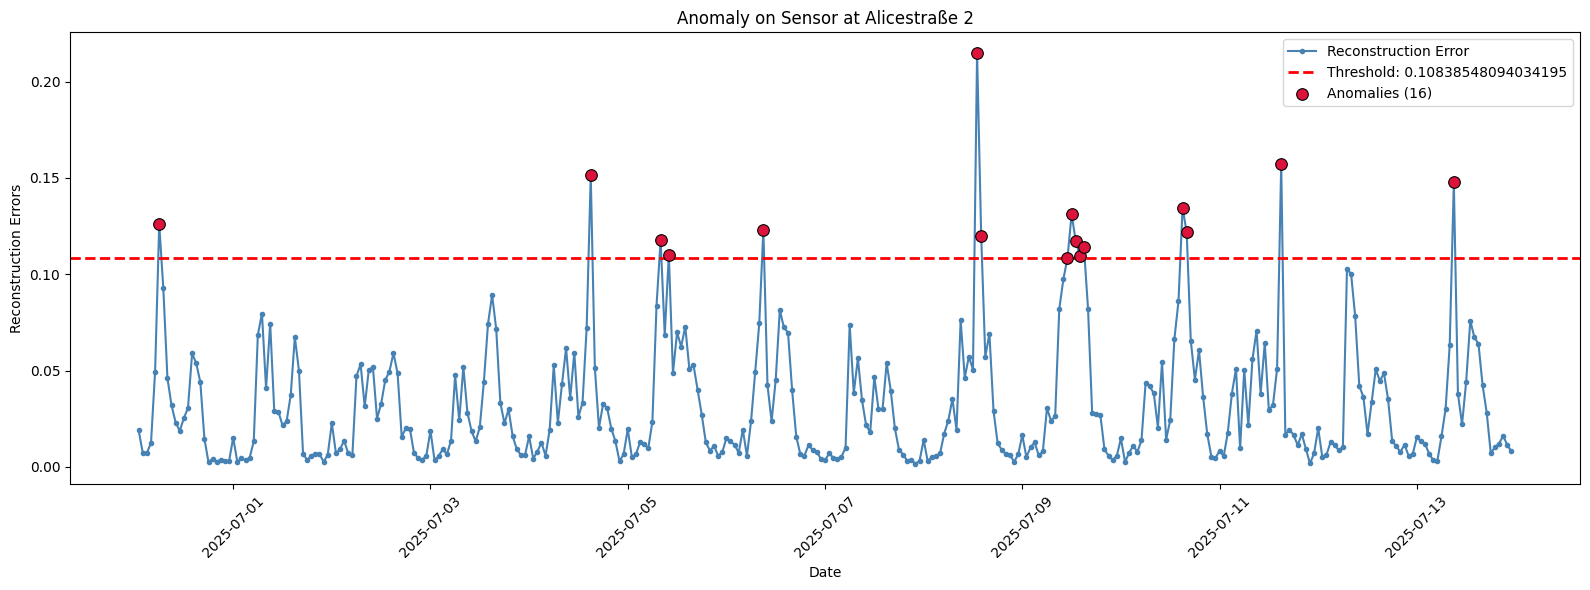

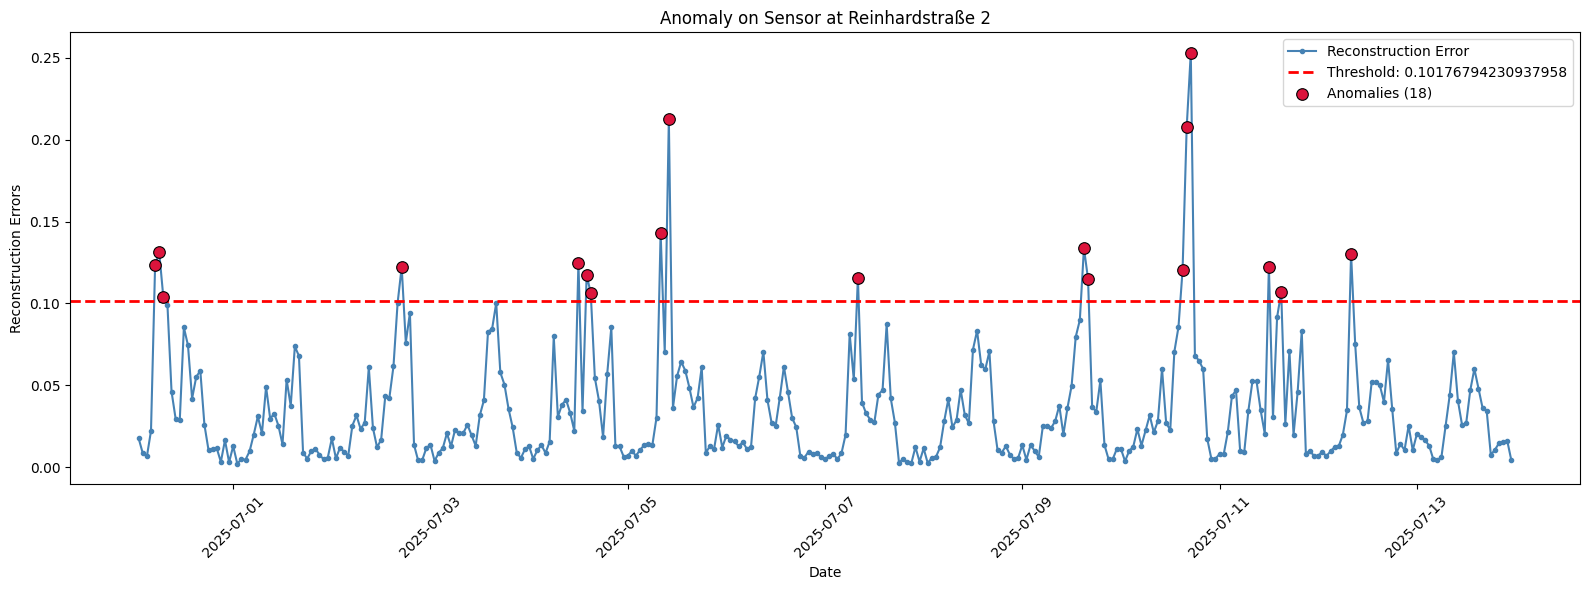

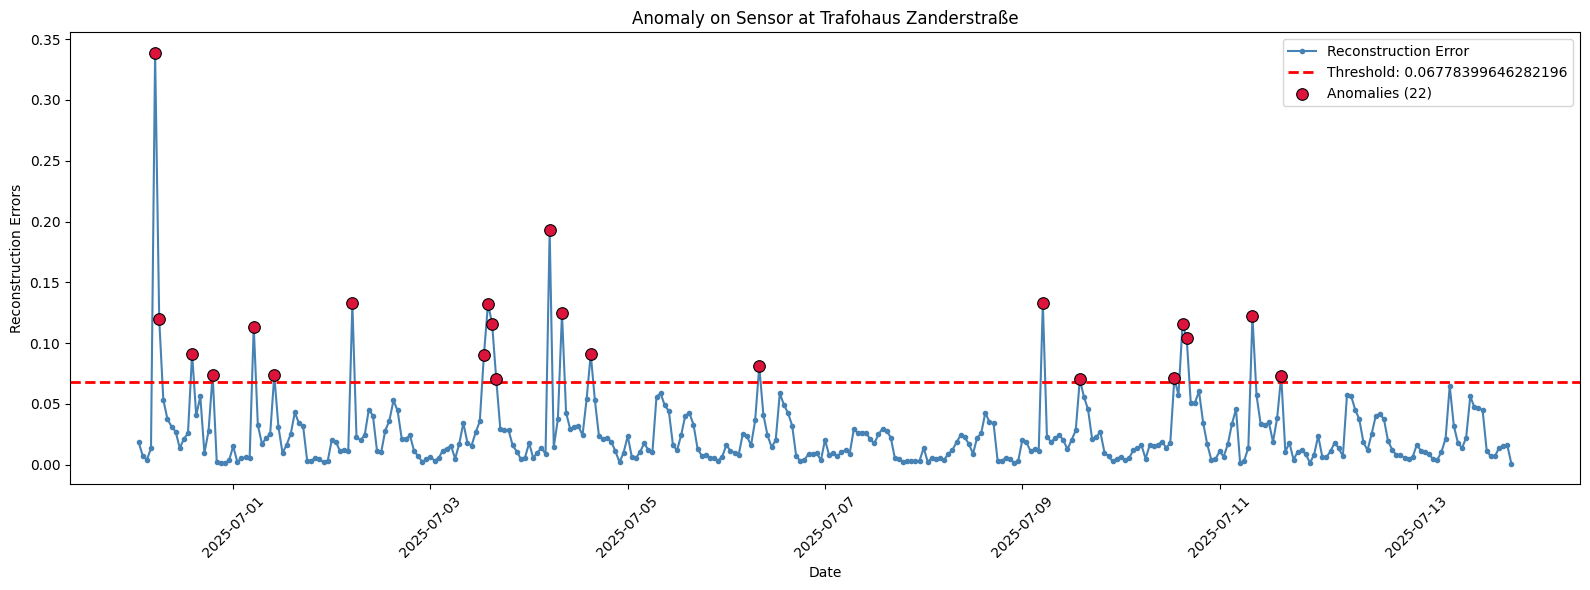

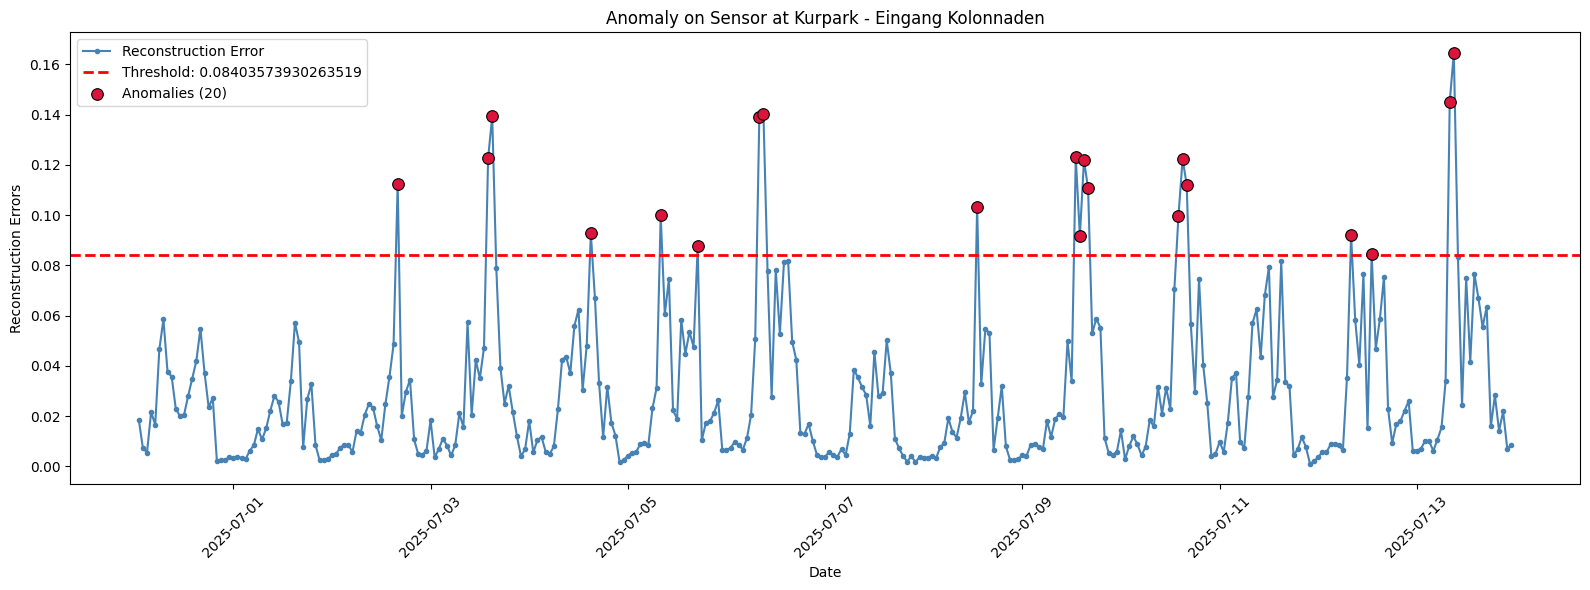

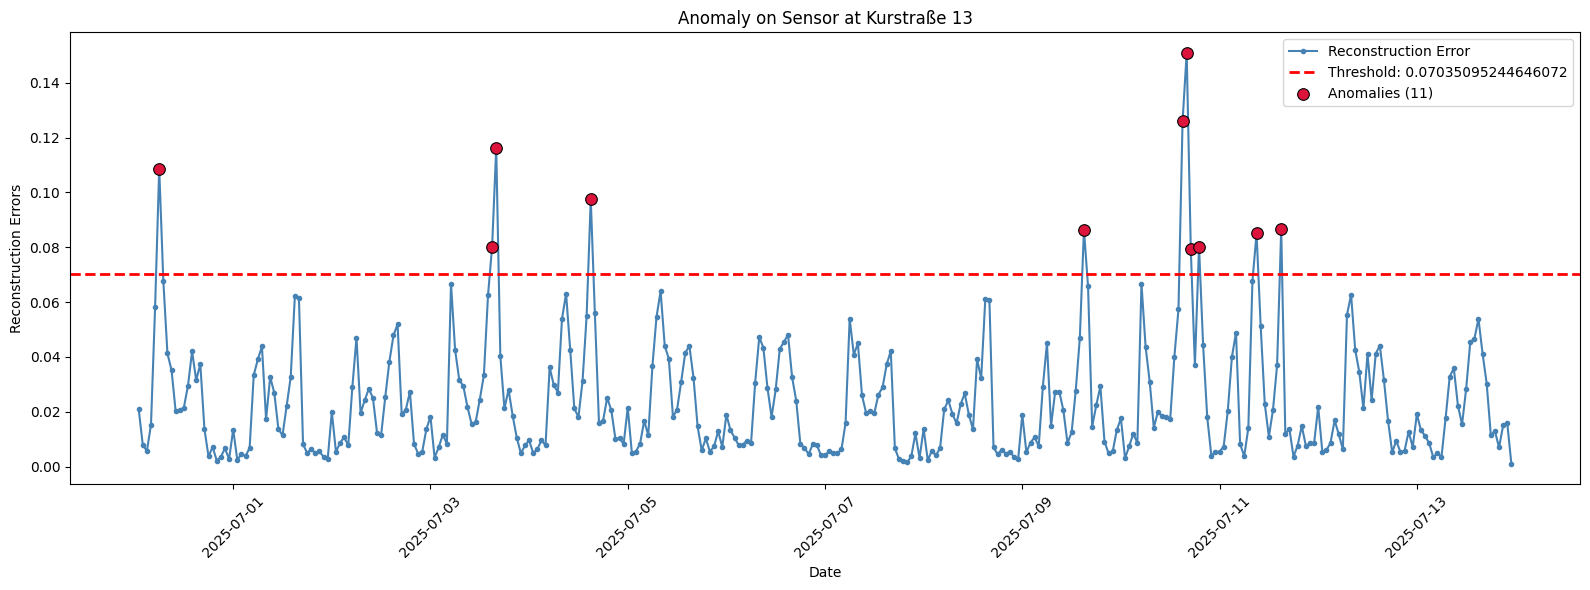

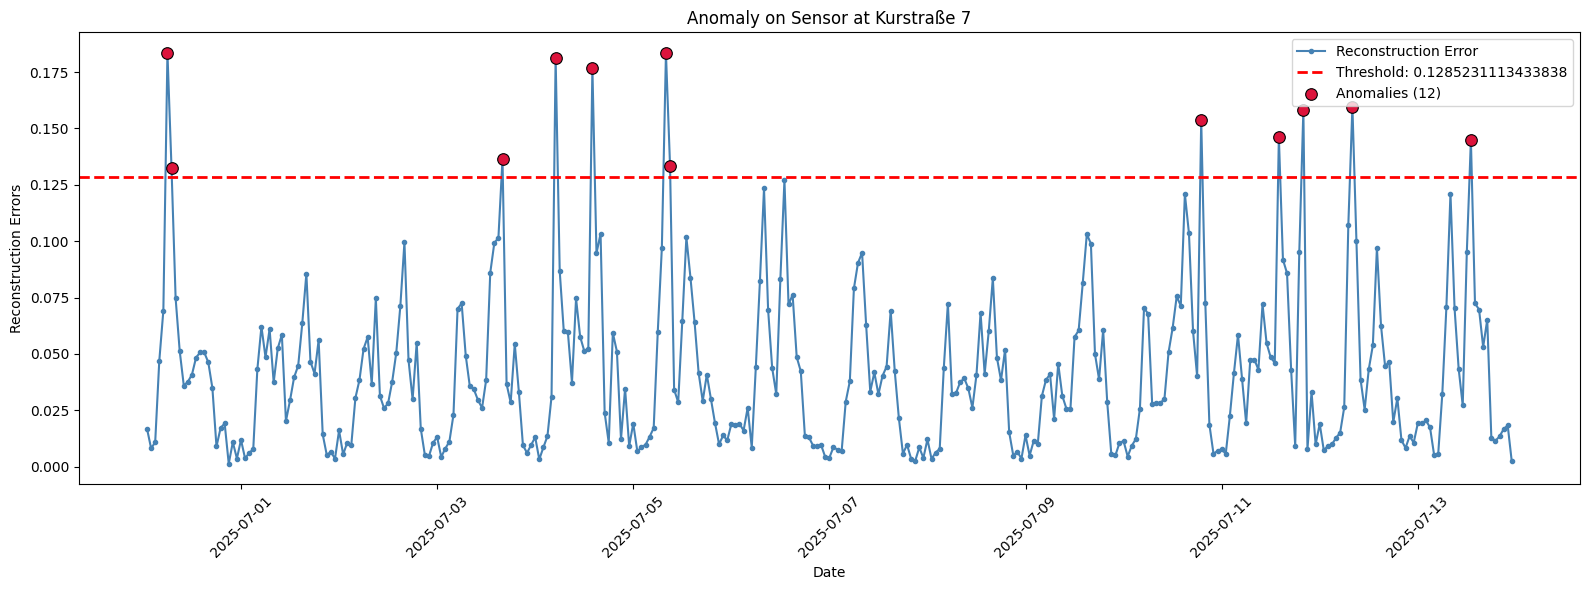

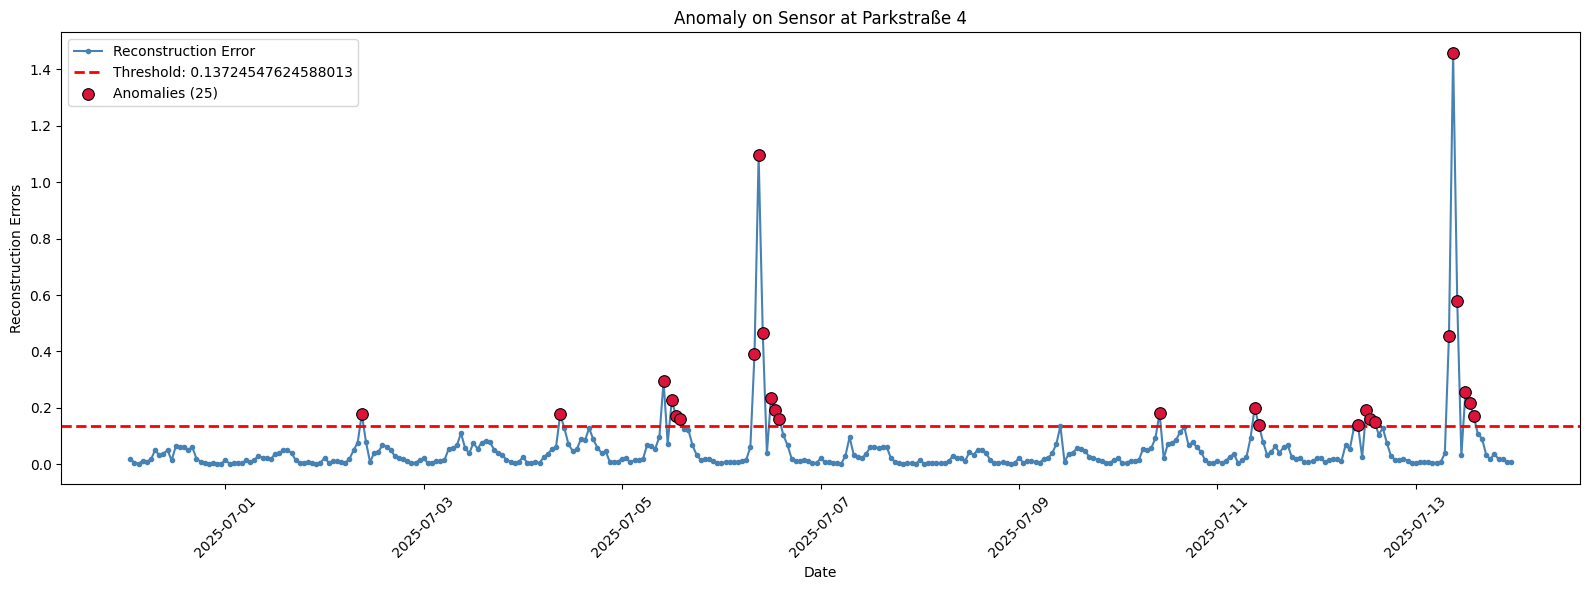

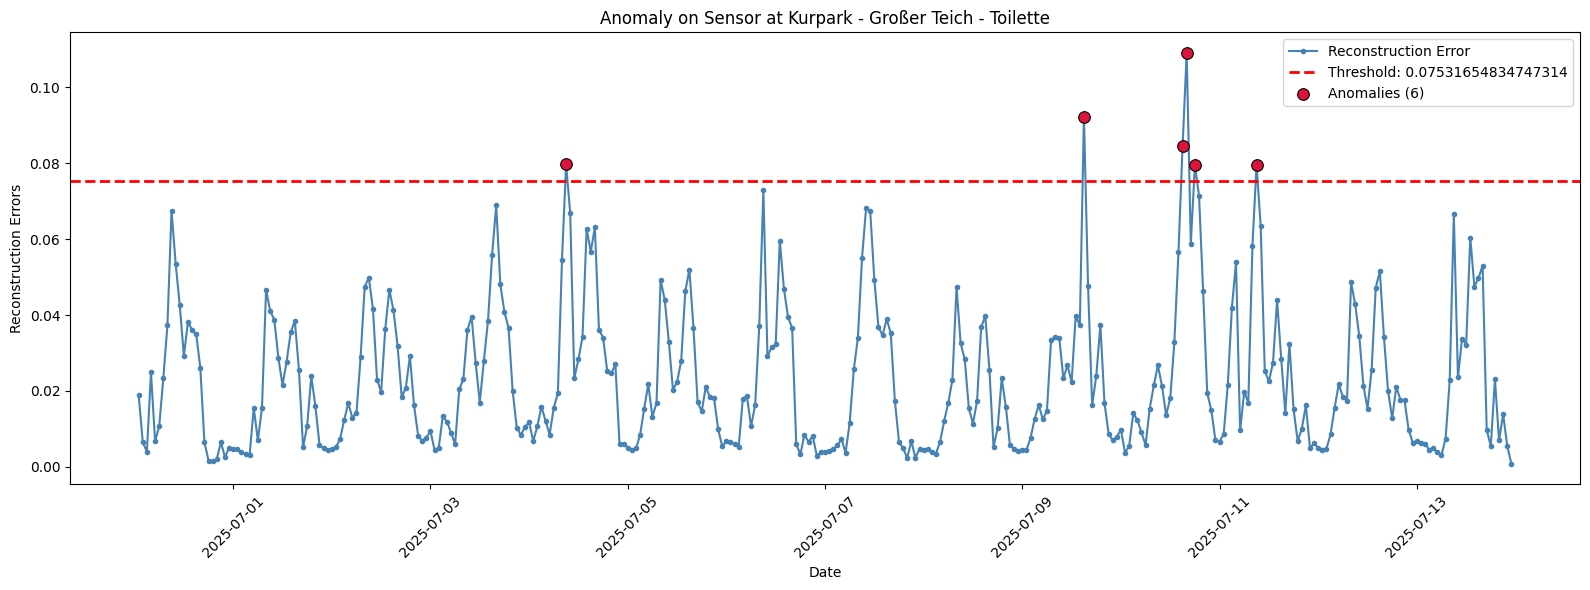

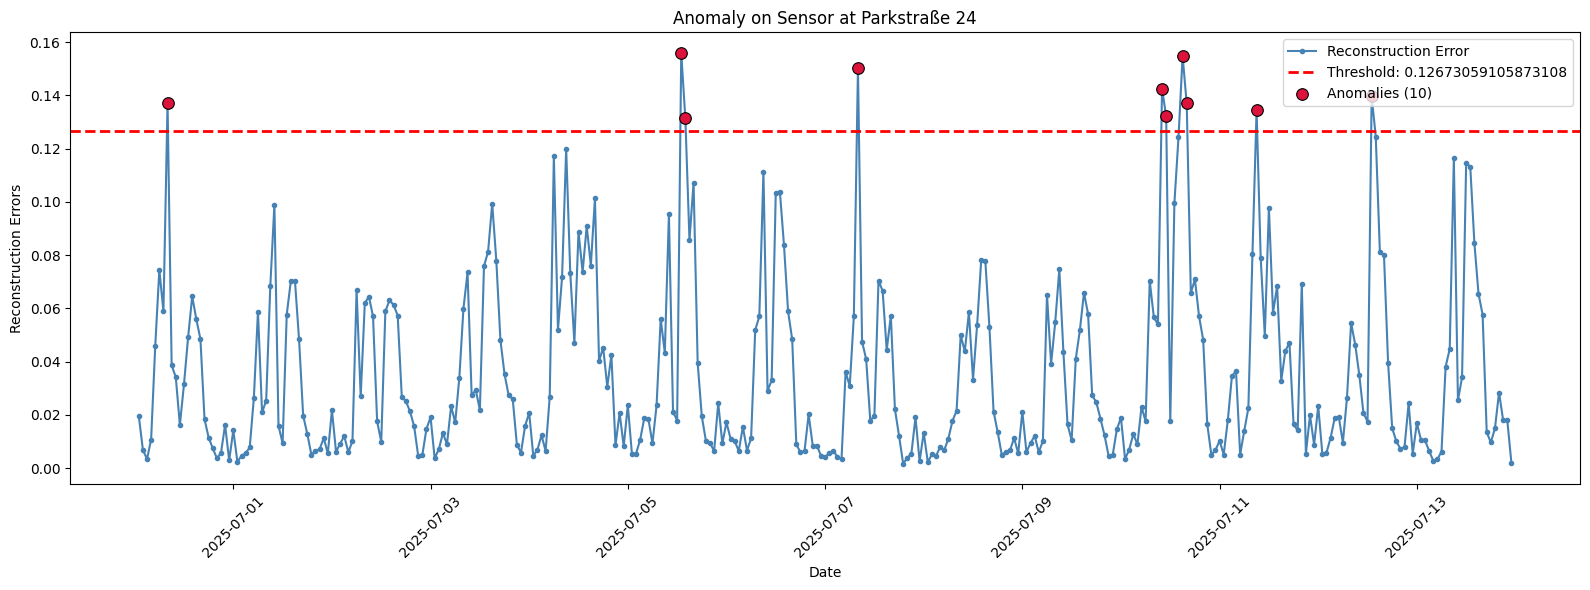

In [39]:
for sensor in sensors:
    anomaly_plot(sensor)

### Generate the Anomaly Report

This function averages reconstruction errors for each timestamp and labels values above the sensor-specific IQR threshold as anomalies. A separate CSV report is saved for each sensor location.


In [40]:
def prepare_anamoly_report(sensor_id:str):
    directory = Path('transformer_anomaly_report')
    directory.mkdir(parents = True, exist_ok=True)
    
    sensor_data = final_result[final_result['SID'] == sensor_id]
    location = sensor_data['location'].iloc[0]
    sensor_data = sensor_data.groupby('timestamp',as_index=False)['error'].mean()
    threshold = iqr_threshold(sensor_data['error'])
    sensor_data['anomaly'] = np.where(
        sensor_data["error"] > threshold,
        "Yes",
        "No")

    output_file = directory/f"{location}.csv"
    sensor_data.to_csv(output_file)

In [41]:
for sensor in sensors:
    prepare_anamoly_report(sensor)

In [42]:
anomaly_data = pd.read_csv('transformer_anomaly_report/Kurpark - Eingang Kurhaus.csv')
anomaly_data.shape
anomaly_data.columns

Index(['Unnamed: 0', 'timestamp', 'error', 'anomaly'], dtype='str')

In [43]:
anomalies = anomaly_data[anomaly_data['anomaly'] == 'Yes']
print(len(anomalies))

19


In [44]:
anomalies

,Unnamed: 0,timestamp,error,anomaly
85,85,2025-07-03 14:00:00+00:00,0.071798,Yes
86,86,2025-07-03 15:00:00+00:00,0.109813,Yes
87,87,2025-07-03 16:00:00+00:00,0.090341,Yes
110,110,2025-07-04 15:00:00+00:00,0.138843,Yes
152,152,2025-07-06 09:00:00+00:00,0.167831,Yes
156,156,2025-07-06 13:00:00+00:00,0.090256,Yes
157,157,2025-07-06 14:00:00+00:00,0.074561,Yes
178,178,2025-07-07 11:00:00+00:00,0.080646,Yes
204,204,2025-07-08 13:00:00+00:00,0.078393,Yes
229,229,2025-07-09 14:00:00+00:00,0.080477,Yes


In [45]:
transformer_model.save('global_model_trans.keras')